# Анализ пользовательского поведения и ключевых метрик маркетплейса

Интернет-маркетплейс собирает данные о заказах, оплатах и активности пользователей.
Компания сталкивается с проблемами:
- снижение конверсии в покупку
- низкий уровень возврата пользователей
- неравномерное распределение выручки

Для повышения эффективности бизнеса необходимо проанализировать пользовательское поведение, выявить узкие места в воронке и предложить продуктовые улучшения.

----

<b>Цель проекта:</b>

Провести комплексный анализ маркетплейса и выявить ключевые факторы, влияющие на конверсию, удержание пользователей и выручку.
Сформировать продуктовые гипотезы для роста ключевых метрик.

---

<b>Задачи проекта</b>

- Изучить и подготовить данные (EDA)
- Проанализировать воронку заказов (conversion funnel)
- Оценить удержание пользователей (retention / повторные покупки)
- Рассчитать ключевые метрики:
    - Conversion Rate
    - Retention
    - ARPU / средний чек
- Выполнить сегментацию пользователей (новые / возвращающиеся / высокоценные)
- Построить аналитический дашборд
- Сформулировать продуктовые выводы и рекомендации

---

<b>Описание данных</b>

Датасет: Brazilian E-Commerce Public Dataset by Olist

- olist_customers_dataset — пользователи                                                                                        
`customer_id` — уникальный идентификатор пользователя                        
`customer_unique_id` — уникальный пользователь (может делать несколько заказов)                       
`customer_city` — город                 
`customer_state` — регион                           

- olist_orders_dataset — заказы                           
`order_id` — идентификатор заказа                        
`customer_id` — идентификатор пользователя                             
`order_status` — статус заказа (created / approved / delivered / canceled и др.)                             
`order_purchase_timestamp` — время создания заказа                         
`order_approved_at` — время подтверждения оплаты                       
`order_delivered_carrier_date` — дата передачи заказа в доставку                      
`order_delivered_customer_date` — дата доставки заказа клиенту                                
`order_estimated_delivery_date` — ожидаемая дата доставки                    

- olist_order_items_dataset — товары в заказе                      
`order_id` — идентификатор заказа                               
`order_item_id` — номер товара внутри заказа                  
`product_id` — идентификатор товара                  
`seller_id` — идентификатор продавца                  
`shipping_limit_date` — крайний срок передачи товара в доставку                  
`price` — стоимость товара                  
`freight_value` — стоимость доставки                                 

- olist_order_payments_dataset — платежи                                   
`order_id` — идентификатор заказа                  
`payment_sequential` — номер платежа внутри заказа                  
`payment_type` — способ оплаты                  
`payment_installments` — количество платежей / рассрочка                  
`payment_value` — сумма платежа (BRL)                                     

Все денежные значения представлены в бразильских реалах (BRL).

<img src="HRhd2Y0.png" width="800">

<a id="11"></a>
## Загрузка данных

In [140]:
pip install adjustText -q

Note: you may need to restart the kernel to use updated packages.


In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import matplotlib.lines as mlines
from adjustText import adjust_text

In [119]:
plt.style.use('default')

sns.set_theme(
    style="whitegrid",
    context="talk"
)

plt.rcParams['figure.figsize'] = (14, 7)

plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'white'

plt.rcParams['axes.edgecolor'] = '#DDDDDD'
plt.rcParams['grid.color'] = '#EEEEEE'

plt.rcParams['axes.labelcolor'] = '#333333'
plt.rcParams['xtick.color'] = '#555555'
plt.rcParams['ytick.color'] = '#555555'

plt.rcParams['text.color'] = '#222222'

plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.titleweight'] = 'bold'

plt.rcParams['axes.labelsize'] = 13

In [3]:
customers = pd.read_csv("olist_customers_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")

In [5]:
def show_df_info(df, name='DataFrame'):
    print(f'\n=== {name} ===')

    print('\nИнформация о данных:')
    df.info() 

    print('\nПервые строки:')
    display(df.head())

    print('\nОписательная статистика:')
    display(df.describe(include='all'))

In [6]:
show_df_info(customers, 'Данные о пользователях')


=== Данные о пользователях ===

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB

Первые строки:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



Описательная статистика:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,06b8999e2fba1a1fbc88172c00ba8bc7,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


Таблица содержит 99441 строку без пропусков. 96 096 уникальных пользователей, больше всего пользователей из Сан-Пауло.

In [9]:
show_df_info(orders, 'Данные о заказах')


=== Данные о заказах ===

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

Первые строки:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



Описательная статистика:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-04-11 10:48:14,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 23:38:46,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


Таблица содержит 99441 строку. Есть пропуски в полях `order_approved_at`(время подтверждения оплаты), `order_delivered_carrier_date` (дата передачи заказа в доставку) и `order_delivered_customer_date` (дата доставки) - скорее всего это отменённые заказы, они не может иметь дату доставки. Временные столбцы необходимо перевести в datetime формат. 

In [16]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

In [8]:
show_df_info(items, 'Данные о товарах в заказах')


=== Данные о товарах в заказах ===

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB

Первые строки:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14



Описательная статистика:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2017-07-21 18:25:23,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000


Таблица содержит 112650 строк без пропусков. Временные столбцы необходимо перевести в datetime формат. Средняя стоимость товара - 120 бразильских реала. Средняя стоимость доставки - 20 реалов. Есть товары с бесплатной доставкой. Самый дешевый товар стоит 0.85 реала, самый дорогой 6 735 реалов.

In [17]:
items['shipping_limit_date'] = pd.to_datetime(items['shipping_limit_date'])

In [12]:
show_df_info(payments, 'Данные о платежах')


=== Данные о платежах ===

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB

Первые строки:


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45



Описательная статистика:


,order_id,payment_sequential,payment_type,payment_installments,payment_value
count,103886,103886.000000,103886,103886.000000,103886.000000
unique,99440,NaN,5,NaN,NaN
top,fa65dad1b0e818e3ccc5cb0e39231352,NaN,credit_card,NaN,NaN
freq,29,NaN,76795,NaN,NaN
mean,NaN,1.092679,NaN,2.853349,154.100380
std,NaN,0.706584,NaN,2.687051,217.494064
min,NaN,1.000000,NaN,0.000000,0.000000
25%,NaN,1.000000,NaN,1.000000,56.790000
50%,NaN,1.000000,NaN,1.000000,100.000000
75%,NaN,1.000000,NaN,4.000000,171.837500


Таблица содержит 103886 строк без пропусков. Чаще всего товары оплачивают кредитной картой. Максимальная рассрочка на 2 года, но чаще всего товар покупают без рассрочки.
`order_id` уникальных только 99 440, так как один заказ может быть оплачен несколькими платежами.

## Исследовательский анализ

### Жизненный цикл заказа

Начинаю анализ с таблицы заказов, так как заказы это центр всей продуктовой логики.

In [18]:
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [22]:
sns.set_theme(style='whitegrid', font_scale=1.1)

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

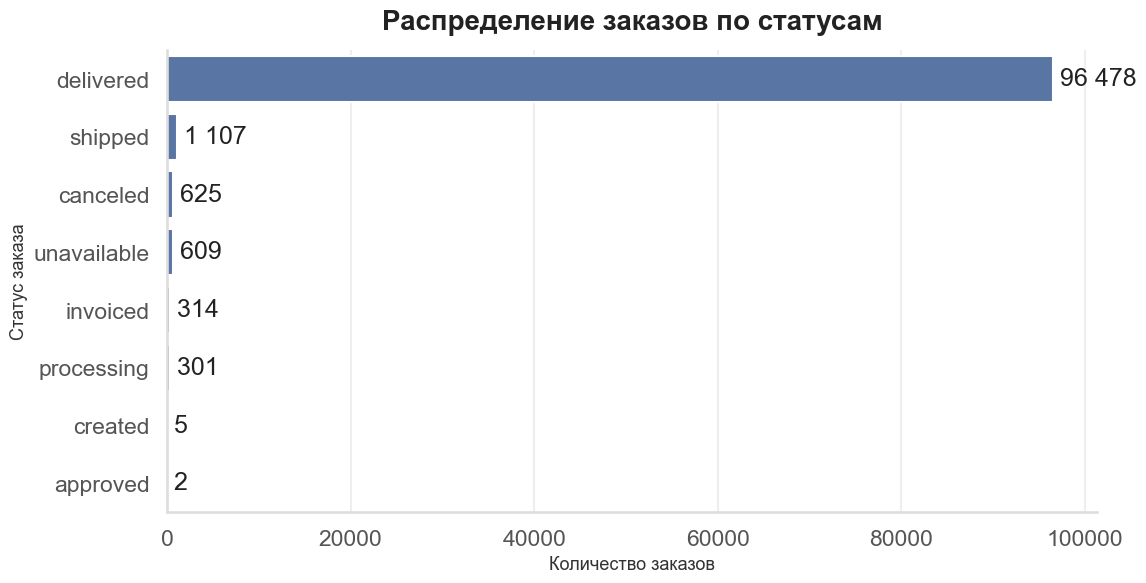

In [120]:
status_counts = orders['order_status'].value_counts()

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x=status_counts.values,
    y=status_counts.index
)

plt.title('Распределение заказов по статусам', pad=15)
plt.xlabel('Количество заказов')
plt.ylabel('Статус заказа')

for i, value in enumerate(status_counts.values):
    ax.text(
        value,
        i,
        f' {value:,}'.replace(',', ' '),
        va='center'
    )

sns.despine()
plt.show()

График показывает, что подавляющее большинство заказов имеют статус delivered, что свидетельствует о стабильной работе платформы и успешном завершении большинства покупок.

При этом в данных присутствуют:

- отменённые заказы (canceled)
- недоступные товары (unavailable)
- заказы в процессе обработки (processing)
- заказы в доставке (shipped)

Доля проблемных заказов относительно невелика, однако даже небольшое количество отмен и недоставок может негативно влиять на пользовательский опыт и уровень доверия к маркетплейсу.

Также заметно, что количество заказов со статусами approved и created крайне мало. Это может быть связано с особенностями формирования датасета или тем, что большая часть заказов уже завершила жизненный цикл.

💡 Возможные продуктовые гипотезы:
- отмены могут быть связаны с проблемами оплаты или логистики;
- статус unavailable может указывать на неточности управления остатками товаров;
- снижение количества отмен способно положительно повлиять на retention пользователей.

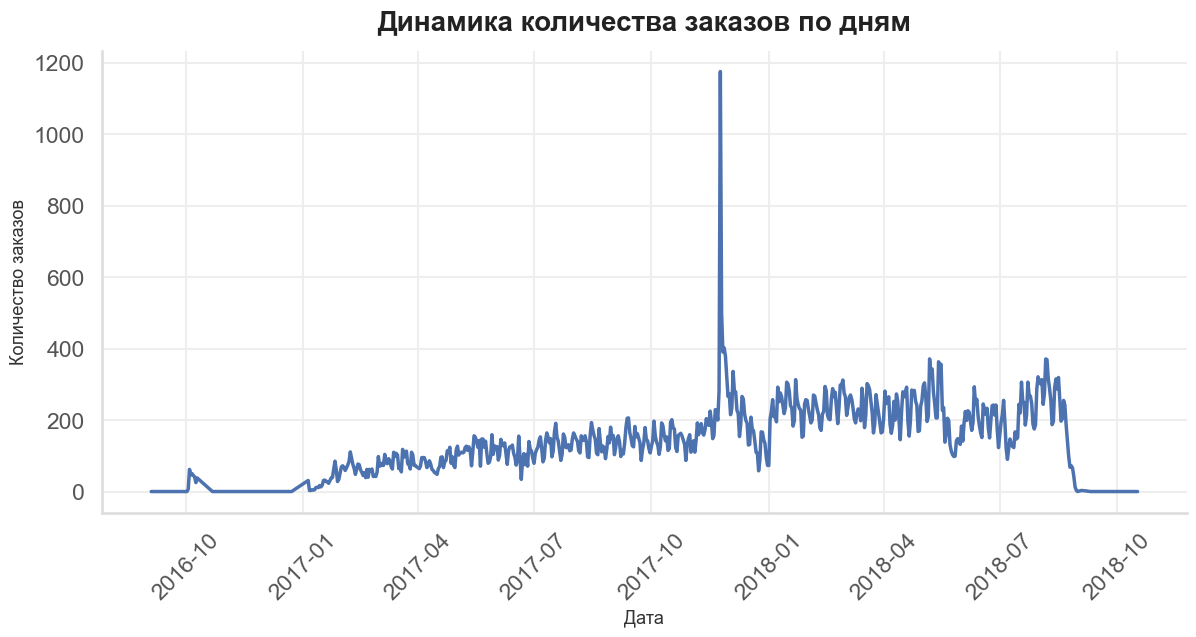

In [121]:
daily_orders = (
    orders
    .groupby(orders['order_purchase_timestamp'].dt.date)
    ['order_id']
    .count()
)

plt.figure(figsize=(14, 6))

sns.lineplot(
    x=daily_orders.index,
    y=daily_orders.values,
    linewidth=2.5
)

plt.title('Динамика количества заказов по дням', pad=15)
plt.xlabel('Дата')
plt.ylabel('Количество заказов')

plt.xticks(rotation=45)
sns.despine()
plt.show()

На графике наблюдается постепенный рост количества заказов с течением времени, что может свидетельствовать о развитии маркетплейса и увеличении пользовательской базы.

Также заметна выраженная сезонность:

- регулярные колебания количества заказов;
- периоды повышенного спроса;
- краткосрочные пики активности.

Особенно выделяется резкий всплеск заказов в конце 2017 года. Вероятно, он связан с крупной маркетинговой кампанией, сезонной распродажей или праздничным периодом.

В конце временного диапазона количество заказов резко снижается практически до нуля. Скорее всего, это связано с неполнотой данных за последние месяцы выгрузки, а не с реальным падением бизнеса.

💡 Возможные продуктовые гипотезы:
- маркетинговые кампании значительно влияют на объём заказов;
- присутствует сезонный пользовательский спрос;
- необходимо учитывать неполные периоды данных при анализе динамики.

In [100]:
orders['delivery_time_days'] = (
    orders['order_delivered_customer_date']
    - orders['order_purchase_timestamp']
).dt.days

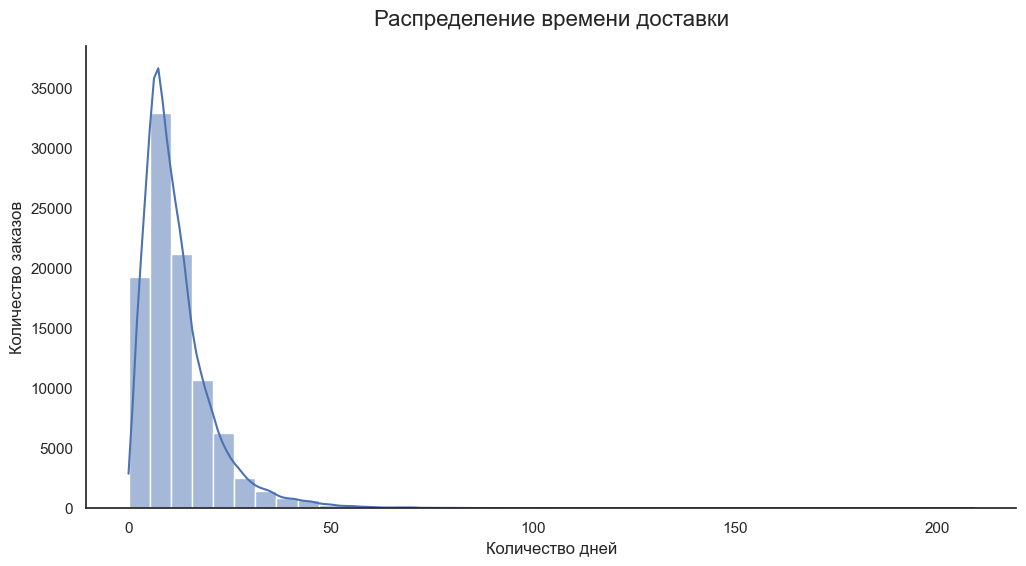

In [101]:
plt.figure(figsize=(12,6))

sns.histplot(
    orders['delivery_time_days'],
    bins=40,
    kde=True
)

plt.title(
    'Распределение времени доставки',
    fontsize=16,
    pad=15
)

plt.xlabel('Количество дней')
plt.ylabel('Количество заказов')

sns.despine()
plt.show()

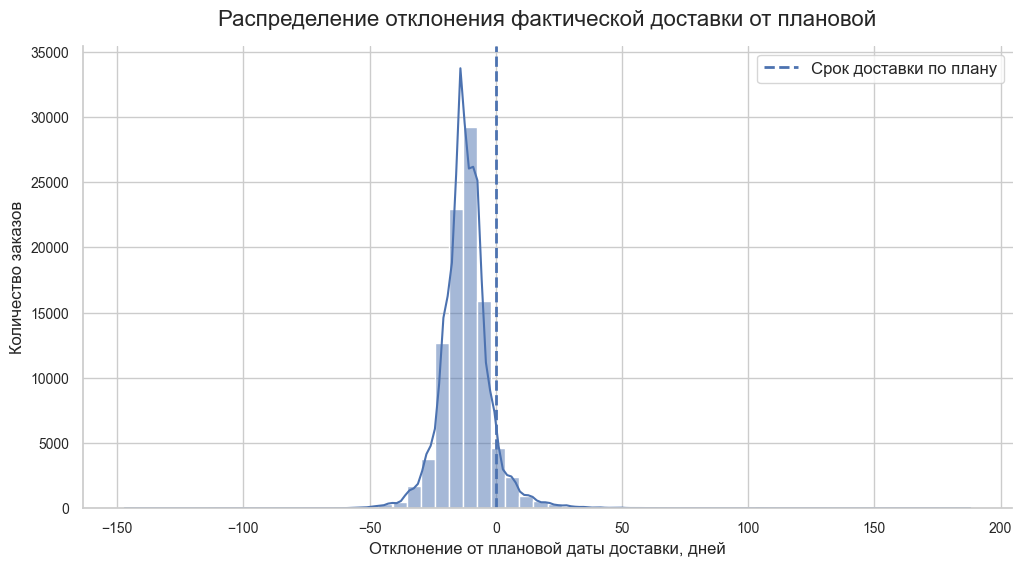

In [25]:
orders['delivery_delay'] = (
    orders['order_delivered_customer_date']
    - orders['order_estimated_delivery_date']
).dt.days

plt.figure(figsize=(12, 6))

sns.histplot(
    data=orders,
    x='delivery_delay',
    bins=60,
    kde=True
)

plt.axvline(
    0,
    linestyle='--',
    linewidth=2,
    label='Срок доставки по плану'
)

plt.title('Распределение отклонения фактической доставки от плановой', pad=15)
plt.xlabel('Отклонение от плановой даты доставки, дней')
plt.ylabel('Количество заказов')

plt.legend()
sns.despine()
plt.show()

График показывает распределение разницы между фактической и ожидаемой датой доставки.

Отрицательные значения означают, что заказ был доставлен раньше ожидаемого срока, а положительные — наличие задержки.

Основная часть заказов сосредоточена в области отрицательных значений, что говорит о том, что большинство доставок выполнялось вовремя или раньше обещанного срока. Это положительно влияет на пользовательский опыт и удовлетворённость клиентов.

При этом присутствует длинный правый хвост распределения — часть заказов доставлялась с существенными задержками. Такие случаи могут негативно влиять на повторные покупки и общий уровень лояльности пользователей.

Также заметны отдельные экстремальные значения задержек, которые могут быть связаны:

- с логистическими проблемами;
- ошибками в данных;
- нестандартными условиями доставки.

💡 Возможные продуктовые гипотезы:
- своевременная доставка может положительно влиять на retention пользователей;
- значительные задержки способны увеличивать вероятность отмен и снижать удовлетворённость клиентов;
- необходимо дополнительно исследовать регионы и продавцов с наибольшими отклонениями по срокам доставки.

### Кто покупает

In [26]:
customers['customer_unique_id'].nunique()

96096

96 096 уникальных пользователей. Посчитаем, сколько заказов приходится на одного пользователя.

In [27]:
customer_orders = orders.merge(
    customers,
    on='customer_id',
    how='left'
)

In [28]:
orders_per_user = customer_orders.groupby(
    'customer_unique_id'
)['order_id'].count()

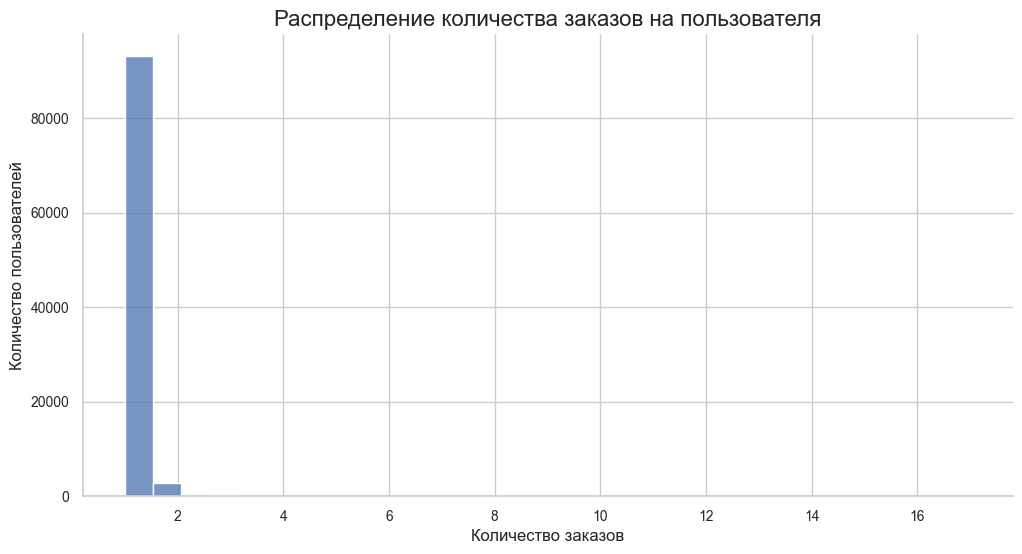

In [29]:
plt.figure(figsize=(12,6))

sns.histplot(
    orders_per_user,
    bins=30
)

plt.title('Распределение количества заказов на пользователя')
plt.xlabel('Количество заказов')
plt.ylabel('Количество пользователей')

sns.despine()
plt.show()

Большая часть пользователей совершает только один заказ, что может свидетельствовать о низком retention и слабом возврате клиентов на платформу. Посмотрим на распределние клиентов по количеству заказов.

In [32]:
orders_per_user.value_counts().head(10)

order_id
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

и в процентах

In [33]:
orders_distribution = (
    orders_per_user
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

orders_distribution.head(10)

order_id
1     96.881244
2      2.856518
3      0.211247
4      0.031219
5      0.008325
6      0.006244
7      0.003122
9      0.001041
17     0.001041
Name: proportion, dtype: float64

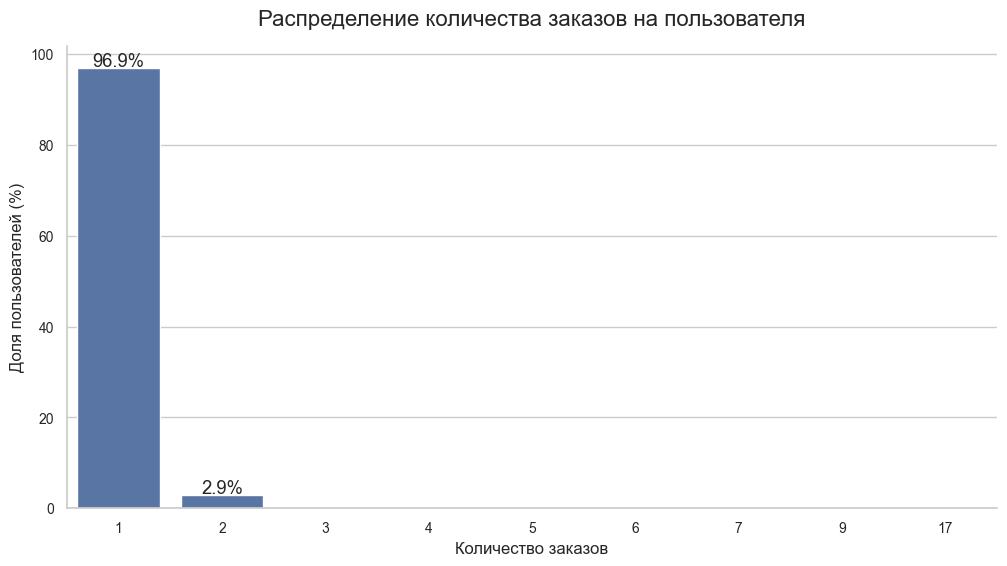

In [34]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=orders_distribution.index,
    y=orders_distribution.values
)

plt.title('Распределение количества заказов на пользователя', pad=15)
plt.xlabel('Количество заказов')
plt.ylabel('Доля пользователей (%)')

for i, value in enumerate(orders_distribution.values):
    if value > 1:
        ax.text(
            i,
            value + 0.5,
            f'{value:.1f}%',
            ha='center'
        )

sns.despine()
plt.show()

Анализ показал, что большая часть пользователей совершает только один заказ на платформе. Доля клиентов с повторными покупками существенно ниже.

Это может свидетельствовать:

- о низком уровне удержания пользователей;
- слабом формировании пользовательской привычки;
- недостаточной эффективности программ лояльности и повторного вовлечения клиентов.

При этом небольшая группа пользователей совершает несколько заказов и потенциально формирует значительную часть выручки маркетплейса.

💡 Возможные продуктовые гипотезы:
- пользователи не получают достаточной ценности после первой покупки;
- повторные продажи могут зависеть от скорости доставки и пользовательского опыта;
- развитие retention-механик способно увеличить LTV клиентов.

In [130]:
top_states = (
    customers['customer_state']
    .value_counts()
    .head(10)
    .sort_values()
)

df_states = top_states.reset_index()

df_states.columns = [
    'state',
    'users_count'
]

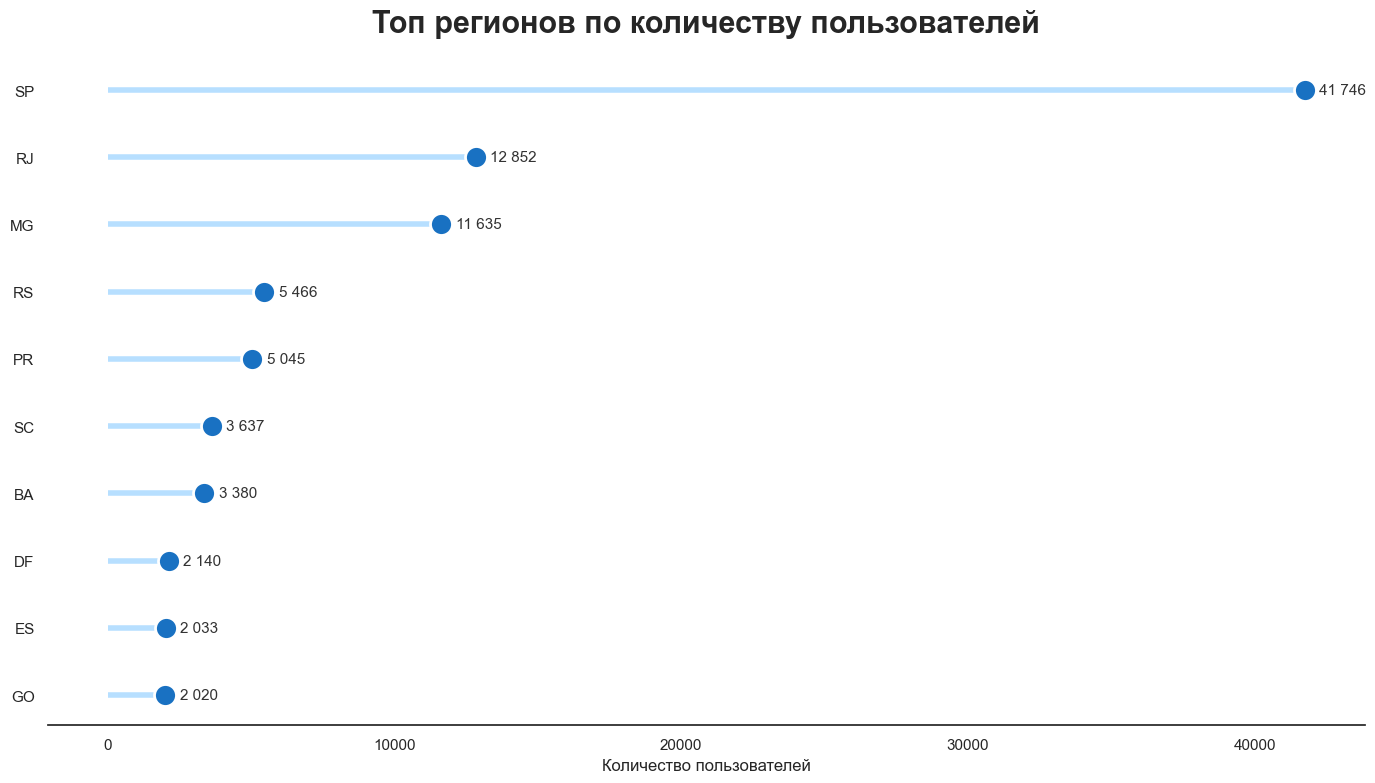

In [131]:
fig, ax = plt.subplots(
    figsize=(14,8),
    dpi=100
)

sns.set_theme(style='whitegrid')

# линии
ax.hlines(
    y=df_states['state'],
    xmin=0,
    xmax=df_states['users_count'],

    color='#A5D8FF',
    linewidth=4,
    alpha=0.8
)

# точки
ax.scatter(
    df_states['users_count'],
    df_states['state'],

    s=250,

    color='#1971C2',
    edgecolors='white',
    linewidths=2,

    zorder=3
)

# подписи значений
for i, row in df_states.iterrows():

    ax.text(
        row['users_count'] + 500,
        row['state'],

        f"{row['users_count']:,}".replace(',', ' '),

        va='center',
        fontsize=11,
        color='#333333'
    )

# title
ax.set_title(
    'Топ регионов по количеству пользователей',
    fontsize=22,
    weight='bold',
    pad=20
)

# labels
ax.set_xlabel('Количество пользователей')
ax.set_ylabel('')

# стиль
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

График показывает значительную концентрацию пользователей в нескольких крупнейших регионах Бразилии. Абсолютным лидером является штат SP (Сан-Паулу), который существенно опережает остальные регионы по количеству клиентов платформы.
Также в число крупнейших регионов входят:
- RJ — Рио-де-Жанейро
- MG — Минас-Жерайс
- RS
- PR

Распределение пользователей выглядит неравномерным: большая часть клиентской базы сосредоточена в ограниченном числе регионов, тогда как остальные штаты имеют значительно меньшую представленность.
Это может быть связано:
- с плотностью населения;
- уровнем развития e-commerce;
- логистической доступностью;
- маркетинговой активностью платформы в конкретных регионах.

Высокая концентрация пользователей в отдельных регионах создаёт как преимущества, так и риски для бизнеса:
- упрощается логистика и масштабирование в ключевых регионах;
- возникает зависимость от ограниченного числа рынков.


💡 Возможные продуктовые гипотезы:

- регионы-лидеры являются основными драйверами выручки маркетплейса;
- в менее представленных регионах существует потенциал для роста пользовательской базы;
- качество доставки и уровень сервиса могут различаться между регионами и влиять на retention пользователей.

### Как платят и сколько приносят денег

In [39]:
payment_counts = payments['payment_type'].value_counts()

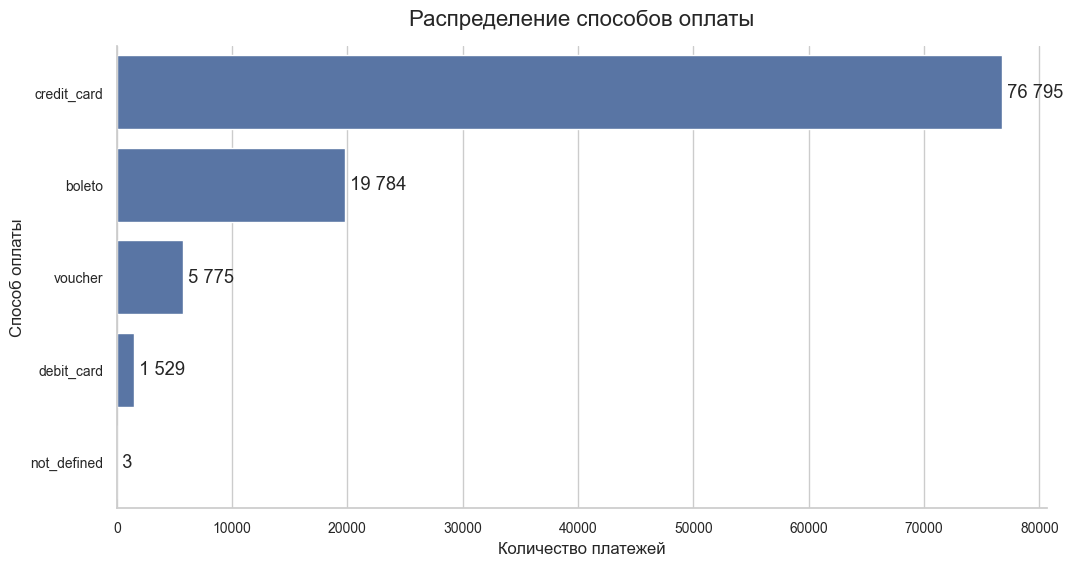

In [40]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=payment_counts.values,
    y=payment_counts.index
)

plt.title('Распределение способов оплаты', pad=15)
plt.xlabel('Количество платежей')
plt.ylabel('Способ оплаты')

for i, value in enumerate(payment_counts.values):
    ax.text(
        value,
        i,
        f' {value:,}'.replace(',', ' '),
        va='center'
    )

sns.despine()
plt.show()

Наиболее популярным способом оплаты является credit_card, который значительно превосходит остальные варианты по количеству транзакций.

Другие способы оплаты (boleto, voucher, debit_card) используются существенно реже.

Доминирование банковских карт может свидетельствовать:

- о высокой популярности безналичных платежей;
- удобстве оплаты картой для пользователей;
- развитии механик оплаты в рассрочку.

Низкая доля альтернативных способов оплаты может ограничивать часть аудитории и влиять на конверсию отдельных сегментов пользователей.

💡 Возможные продуктовые гипотезы:
- пользователи предпочитают наиболее быстрые и удобные способы оплаты;
- расширение доступных payment-методов может положительно повлиять на conversion rate;
- использование кредитных карт может быть связано с более высоким средним чеком.

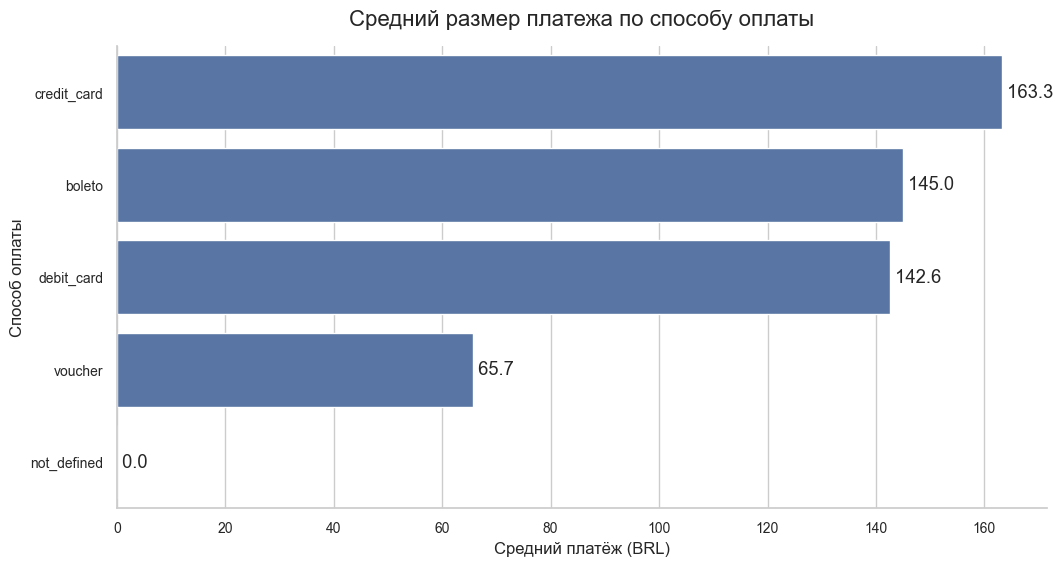

In [41]:
avg_payment = (
    payments
    .groupby('payment_type')['payment_value']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=avg_payment.values,
    y=avg_payment.index
)

plt.title('Средний размер платежа по способу оплаты', pad=15)
plt.xlabel('Средний платёж (BRL)')
plt.ylabel('Способ оплаты')

for i, value in enumerate(avg_payment.values):
    ax.text(
        value,
        i,
        f' {value:.1f}',
        va='center'
    )

sns.despine()
plt.show()

Средний размер платежа различается в зависимости от выбранного способа оплаты. Это может указывать на различия в пользовательском поведении и сценариях покупок.

Пользователи, использующие определённые способы оплаты, потенциально совершают более крупные заказы.

Такие различия могут быть связаны:

- с доступностью рассрочки;
- уровнем доверия к способу оплаты;
- особенностями пользовательских сегментов.

💡 Возможные продуктовые гипотезы:
- пользователи кредитных карт чаще совершают дорогие покупки;
- рассрочка может стимулировать увеличение среднего чека;
- определённые способы оплаты могут быть более характерны для лояльных пользователей.

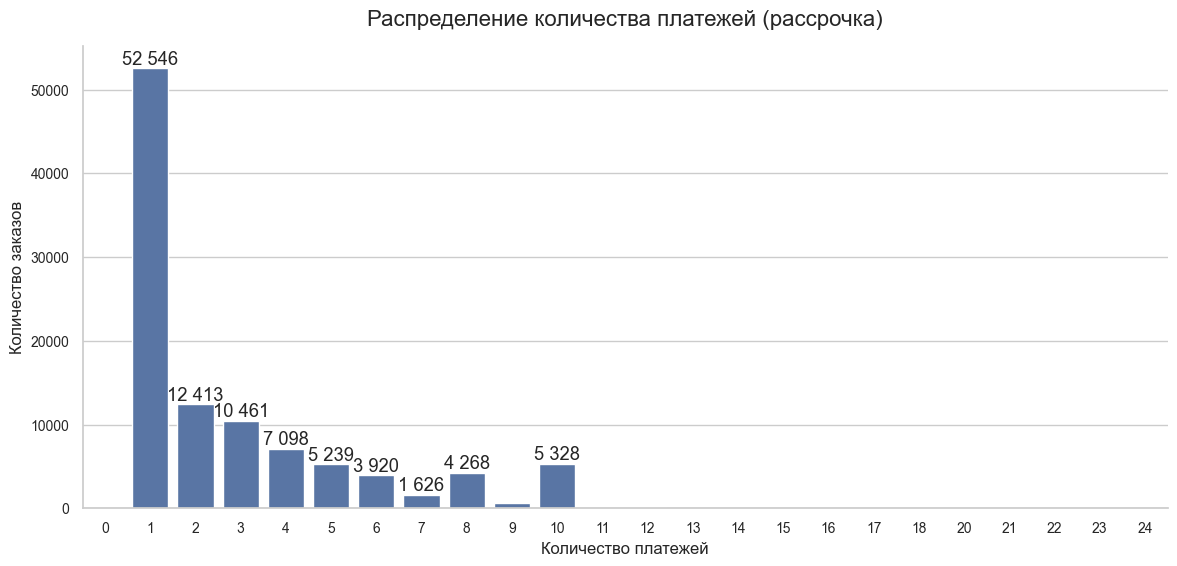

In [42]:
installments = payments['payment_installments'].value_counts().sort_index()

plt.figure(figsize=(14,6))

ax = sns.barplot(
    x=installments.index,
    y=installments.values
)

plt.title('Распределение количества платежей (рассрочка)', pad=15)
plt.xlabel('Количество платежей')
plt.ylabel('Количество заказов')

for i, value in enumerate(installments.values):
    if value > 1000:
        ax.text(
            i,
            value,
            f'{value:,}'.replace(',', ' '),
            ha='center',
            va='bottom'
        )

sns.despine()
plt.show()

Большая часть заказов оплачивается одним платежом, однако значительная доля пользователей использует оплату в рассрочку.

Это может говорить о:

- востребованности гибких финансовых условий;
- высокой роли кредитных инструментов в e-commerce;
- стремлении пользователей распределять крупные расходы.

Также заметно, что количество заказов постепенно снижается при увеличении числа платежей, что соответствует ожидаемому пользовательскому поведению.

💡 Возможные продуктовые гипотезы:
- наличие рассрочки положительно влияет на conversion rate;
- пользователи с большим количеством платежей могут иметь более высокий средний чек;
- развитие BNPL/credit-механик может увеличить GMV маркетплейса.

In [103]:
order_revenue = (
    payments.groupby('order_id')['payment_value']
    .sum()
)

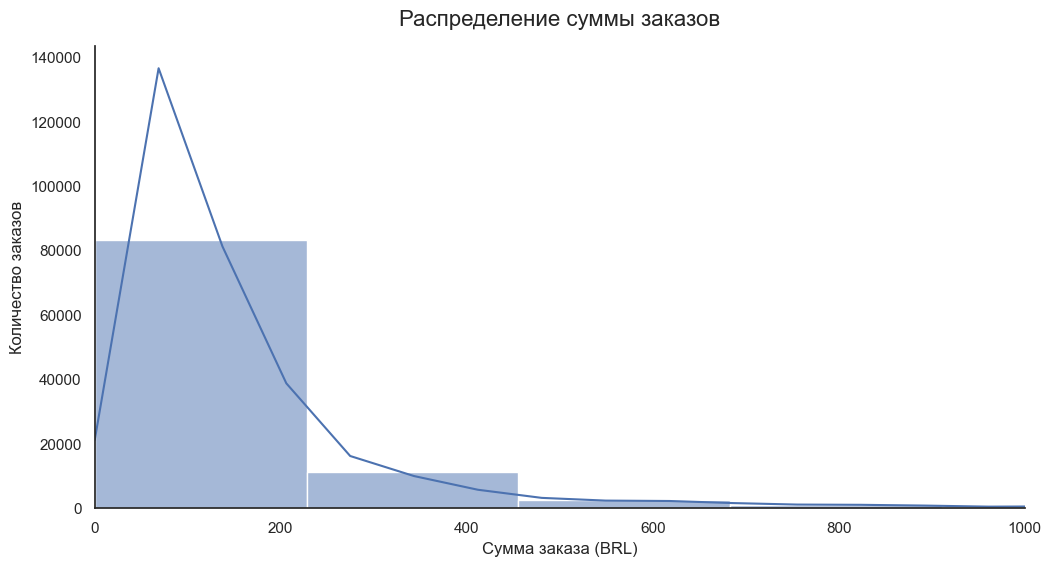

In [104]:
plt.figure(figsize=(12,6))

sns.histplot(
    order_revenue,
    bins=60,
    kde=True
)

plt.title(
    'Распределение суммы заказов',
    fontsize=16,
    pad=15
)

plt.xlabel('Сумма заказа (BRL)')
plt.ylabel('Количество заказов')

plt.xlim(0, 1000)

sns.despine()
plt.show()

График показывает, что большинство заказов на маркетплейсе имеют относительно небольшую стоимость. Основная масса покупок сосредоточена в диапазоне низких и средних чеков, тогда как дорогие заказы встречаются значительно реже.

Распределение имеет ярко выраженный правосторонний хвост: присутствует небольшое количество заказов с очень высокой стоимостью, которые формируют выбросы и существенно отличаются от основной массы транзакций.

Подобная структура характерна для e-commerce платформ:

- большое количество недорогих повседневных покупок;
- ограниченное число крупных заказов с высоким вкладом в revenue.

Наличие длинного хвоста может говорить о существовании сегмента high-value пользователей, совершающих более дорогие покупки.

💡 Возможные продуктовые гипотезы:
- основную стабильность revenue обеспечивают массовые недорогие покупки;
- крупные заказы могут формироваться ограниченной группой пользователей;
- персонализированные рекомендации и программы лояльности способны увеличивать средний чек.

### Анализ товаров и структуры заказов

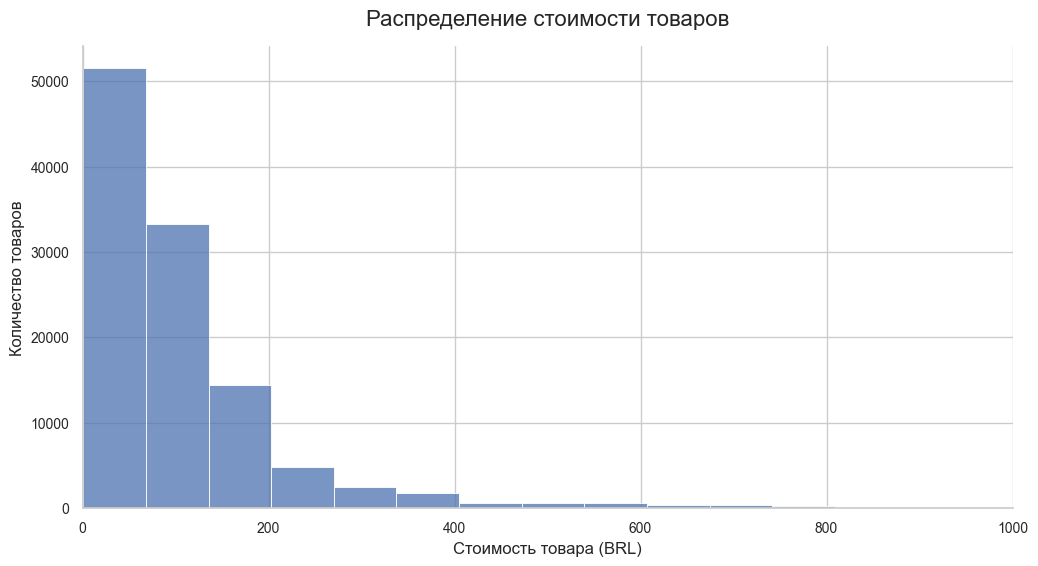

In [43]:
plt.figure(figsize=(12,6))

sns.histplot(
    items['price'],
    bins=100
)

plt.title('Распределение стоимости товаров', pad=15)
plt.xlabel('Стоимость товара (BRL)')
plt.ylabel('Количество товаров')

plt.xlim(0, 1000)

sns.despine()
plt.show()

Большая часть товаров находится в низком и среднем ценовом диапазоне. При этом присутствует длинный правый хвост распределения — небольшая доля товаров имеет значительно более высокую стоимость.

Такое распределение характерно для e-commerce платформ:

- основную массу заказов формируют недорогие товары;
- дорогие товары встречаются существенно реже.

Наличие высокоценных товаров может оказывать значительное влияние на общую выручку маркетплейса.

💡 Возможные продуктовые гипотезы:
- основной объём продаж формируется за счёт массового сегмента;
- premium-сегмент может генерировать значительную долю GMV;
- пользователи могут быть чувствительны к стоимости доставки относительно цены товара.

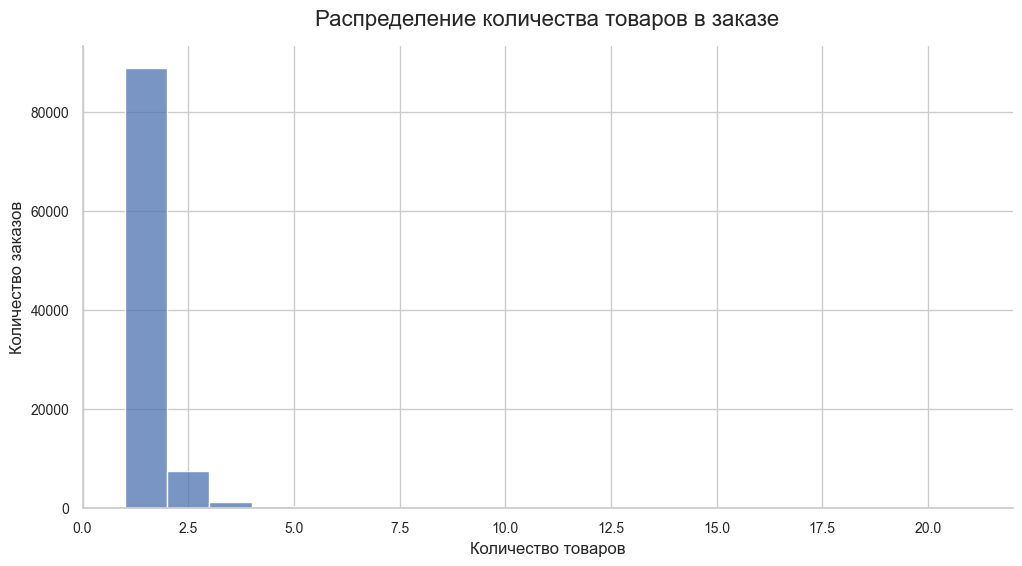

In [48]:
items_per_order = (
    items
    .groupby('order_id')['order_item_id']
    .count()
)

plt.figure(figsize=(12,6))

sns.histplot(
    items_per_order,
    bins=20
)

plt.title('Распределение количества товаров в заказе', pad=15)
plt.xlabel('Количество товаров')
plt.ylabel('Количество заказов')

sns.despine()
plt.show()

Большинство заказов содержит один товар, тогда как многотоварные корзины встречаются значительно реже.

Это может свидетельствовать о:

- преобладании точечных покупок;
- низком уровне cross-sell / up-sell;
- пользовательском поведении, ориентированном на отдельные товары.

При этом небольшая часть заказов содержит сразу несколько товаров, что потенциально увеличивает средний чек маркетплейса.

💡 Возможные продуктовые гипотезы:
- рекомендации сопутствующих товаров могут увеличить размер корзины;
- механики bundle / наборов способны повысить AOV;
- бесплатная доставка от определённой суммы может стимулировать multi-item заказы.

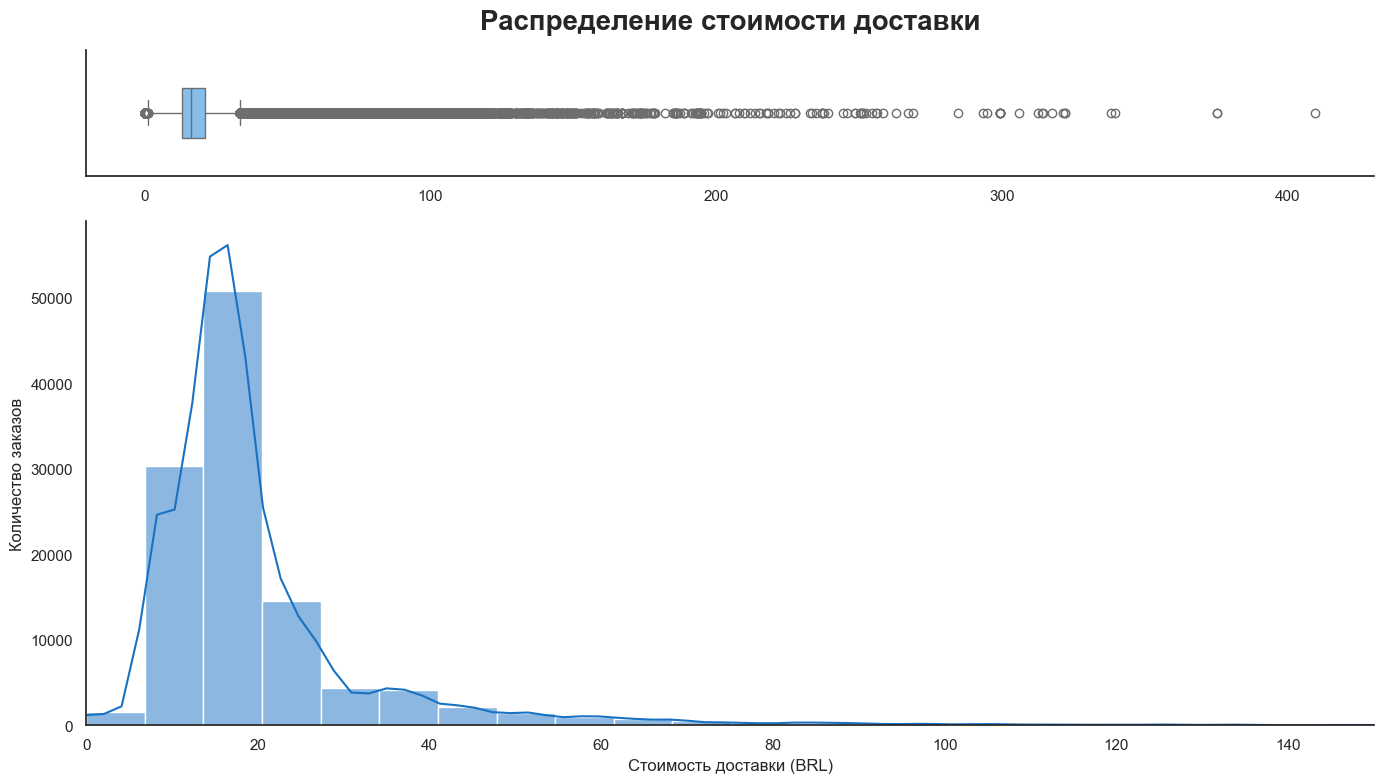

In [188]:
fig, axes = plt.subplots(
    2,
    1,

    figsize=(14,8),

    gridspec_kw={
        'height_ratios': [1, 4]
    }
)

sns.set_theme(style='whitegrid')

# BOXPLOT
sns.boxplot(
    x=items['freight_value'],

    ax=axes[0],

    color='#74C0FC',

    width=0.4
)

# HISTOGRAM
sns.histplot(
    items['freight_value'],

    bins=60,
    kde=True,

    ax=axes[1],

    color='#1971C2'
)

axes[0].set_title(
    'Распределение стоимости доставки',
    fontsize=20,
    weight='bold',
    pad=15
)

axes[0].set_xlabel('')
axes[0].set_ylabel('')

axes[1].set_xlabel('Стоимость доставки (BRL)')
axes[1].set_ylabel('Количество заказов')

# ограничим хвост
axes[1].set_xlim(0, 150)

sns.despine()

plt.tight_layout()
plt.show()

Большинство заказов имеет относительно невысокую стоимость доставки, однако присутствуют отдельные заказы с существенно более дорогой логистикой.

Стоимость доставки является важным фактором пользовательского опыта и может напрямую влиять на конверсию в покупку.

Высокая стоимость доставки особенно чувствительна для недорогих товаров, где логистика занимает значительную долю итоговой стоимости заказа.

💡 Возможные продуктовые гипотезы:
- высокая стоимость доставки может снижать conversion rate;
- пользователи могут чаще отказываться от дешёвых товаров при дорогой доставке;
- субсидирование доставки способно увеличить средний размер корзины.

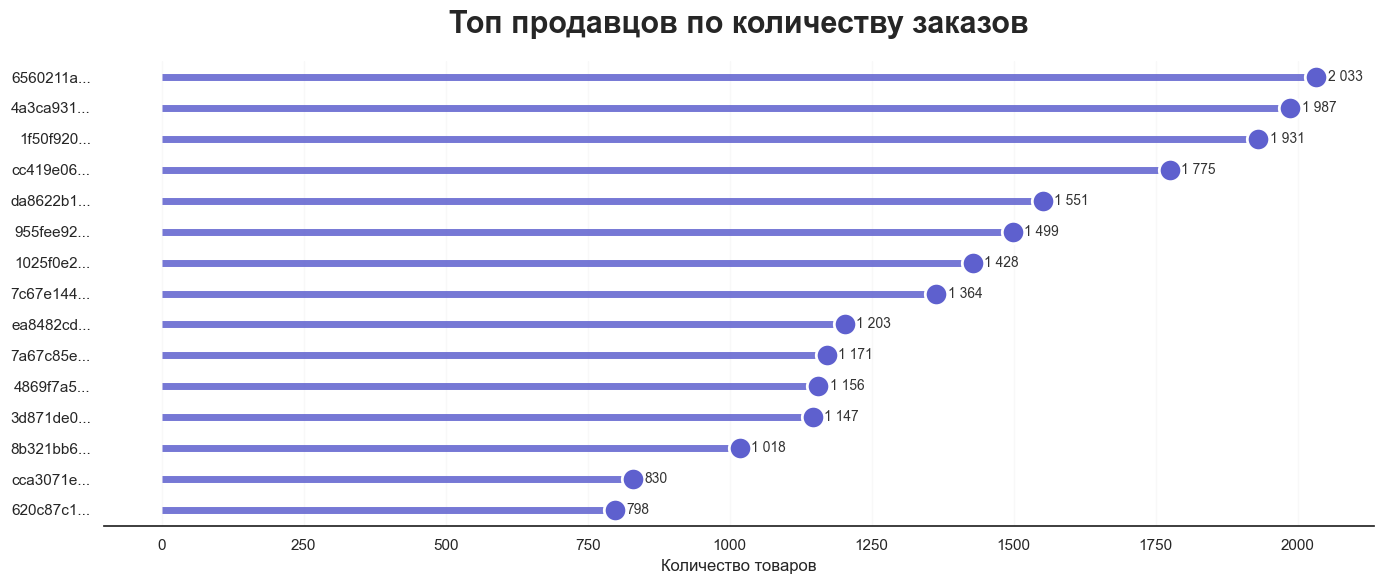

In [187]:
top_sellers = items['seller_id'].value_counts().head(15)

top_sellers_plot = (
    top_sellers
    .sort_values()
)

fig, ax = plt.subplots(figsize=(14, 6), dpi=100)

# palette
color = '#5E60CE'

# компактные позиции
y_pos = [i * 0.38 for i in range(len(top_sellers_plot))]

# линии
ax.hlines(
    y=y_pos,
    xmin=0,
    xmax=top_sellers_plot.values,

    color=color,
    linewidth=5,
    alpha=0.85
)

# точки
ax.scatter(
    top_sellers_plot.values,
    y_pos,
    s=260,
    color=color,
    edgecolors='white',
    linewidths=2,
    zorder=3
)

# подписи справа
for i, (user, value) in enumerate(top_sellers_plot.items()):

    ax.text(
        value + 20,
        y_pos[i],
        f"{value:,.0f}".replace(',', ' '),
        va='center',
        fontsize=10,
        color='#333333'
    )

# оси
ax.set_yticks(y_pos)

# сокращаем seller id
ax.set_yticklabels(
    [u[:8] + '...' for u in top_sellers_plot.index],
    fontsize=11
)

# title
ax.set_title(
    'Топ продавцов по количеству заказов',
    fontsize=22,
    weight='bold',
    pad=20
)

ax.set_xlabel('Количество товаров')
ax.set_ylabel('')

# limits
ax.set_ylim(-0.2, max(y_pos) + 0.2)

# стиль
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.grid(axis='y', alpha=0)
ax.grid(axis='x', alpha=0.12)

plt.tight_layout()
plt.show()

График показывает, что объём продаж распределён между продавцами неравномерно. Небольшая группа sellers формирует существенно больше товарных позиций в заказах по сравнению с остальными участниками платформы.

Это может свидетельствовать о высокой концентрации активности вокруг ограниченного числа крупных продавцов.

Подобное распределение характерно для маркетплейсов:

- часть продавцов выступает ключевыми драйверами оборота;
- основная масса sellers имеет значительно меньший объём продаж.

Высокая зависимость платформы от небольшого числа крупных продавцов может создавать бизнес-риски:

- влияние на ассортимент;
- влияние на выручку;
- потенциальные проблемы при уходе крупных партнёров.

Одновременно такие продавцы могут обеспечивать:

- стабильный поток заказов;
- более широкий ассортимент;
- высокую доступность товаров.

💡 Возможные продуктовые гипотезы:
- крупные продавцы являются основными драйверами GMV маркетплейса;
- развитие малого и среднего seller-сегмента может снизить зависимость от крупных партнёров;
- качество сервиса и скорость доставки у крупных продавцов могут напрямую влиять на пользовательский опыт.

### Объединение таблиц

In [52]:
df = orders.merge(
    customers,
    on='customer_id',
    how='left'
)

In [53]:
df = df.merge(
    payments,
    on='order_id',
    how='left'
)

In [54]:
df = df.merge(
    items,
    on='order_id',
    how='left'
)

In [55]:
df.shape

(118434, 23)

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118434 entries, 0 to 118433
Data columns (total 23 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       118434 non-null  object        
 1   customer_id                    118434 non-null  object        
 2   order_status                   118434 non-null  object        
 3   order_purchase_timestamp       118434 non-null  datetime64[ns]
 4   order_approved_at              118258 non-null  datetime64[ns]
 5   order_delivered_carrier_date   116360 non-null  datetime64[ns]
 6   order_delivered_customer_date  115037 non-null  datetime64[ns]
 7   order_estimated_delivery_date  118434 non-null  datetime64[ns]
 8   delivery_delay                 115037 non-null  float64       
 9   customer_unique_id             118434 non-null  object        
 10  customer_zip_code_prefix       118434 non-null  int64         
 11  

In [57]:
(
    df.isna().mean() * 100
).sort_values(ascending=False)

order_delivered_customer_date    2.868264
delivery_delay                   2.868264
order_delivered_carrier_date     1.751186
freight_value                    0.700812
price                            0.700812
shipping_limit_date              0.700812
seller_id                        0.700812
product_id                       0.700812
order_item_id                    0.700812
order_approved_at                0.148606
payment_type                     0.002533
payment_value                    0.002533
payment_installments             0.002533
payment_sequential               0.002533
order_id                         0.000000
customer_state                   0.000000
customer_id                      0.000000
customer_zip_code_prefix         0.000000
customer_unique_id               0.000000
order_estimated_delivery_date    0.000000
order_purchase_timestamp         0.000000
order_status                     0.000000
customer_city                    0.000000
dtype: float64

После объединения таблиц были обнаружены пропуски в ряде признаков. Большая часть отсутствующих значений связана не с ошибками данных, а с особенностями бизнес-процессов маркетплейса.

Наибольшая доля пропусков наблюдается в полях:

- `order_delivered_customer_date`
- `delivery_delay`
- `order_delivered_carrier_date`

Это связано с тем, что часть заказов:

- была отменена;
- находилась в процессе обработки;
- не дошла до этапа доставки.

В подобных случаях отсутствие даты доставки является ожидаемым и отражает жизненный цикл заказа.

Пропуски в:

- `price`
- `freight_value`
- `seller_id`
- `product_id`
- `shipping_limit_date`

появились после объединения таблиц и составляют менее 1% данных. Вероятнее всего, они связаны:

- с отсутствием информации по отдельным товарным позициям;
- особенностями canceled/unavailable заказов;
- неполными связями между таблицами.

Также присутствует небольшое количество пропусков в:

- `payment_type`
- `payment_value`
- `payment_installments`

Доля таких записей крайне мала и не оказывает существенного влияния на общий анализ.

Пропуски в `order_approved_at` могут указывать на заказы, которые не дошли до этапа подтверждения оплаты.

В целом качество данных можно оценить как высокое. Критически важных потерь данных не обнаружено, большинство пропусков имеют логичное бизнес-объяснение.

## Ключевые метрики

Выручка (Revenue)

In [64]:
revenue = (
    payments['payment_value']
    .sum()
)

print(f'Total revenue: {revenue:,.2f} BRL')

Total revenue: 16,008,872.12 BRL


Средний чек (AOV)

In [59]:
aov = (
    payments
    .groupby('order_id')['payment_value']
    .sum()
    .mean()
)

print(f'Average Order Value: {aov:.2f} BRL')

Average Order Value: 160.99 BRL


Уникальные пользователи (User Base)

In [60]:
customers['customer_unique_id'].nunique()

96096

Среднее количество товаров в заказе (Basket Size)

In [61]:
avg_items = (
    items
    .groupby('order_id')['order_item_id']
    .count()
    .mean()
)

print(f'Average items per order: {avg_items:.2f}')

Average items per order: 1.14


## Анализ клиентского пути

Для оценки пользовательского опыта была построена воронка прохождения заказа через ключевые этапы клиентского пути.

In [65]:
funnel = {
    'Создан заказ': orders['order_id'].nunique(),

    'Подтверждён': orders[
        orders['order_approved_at'].notna()
    ]['order_id'].nunique(),

    'Передан в доставку': orders[
        orders['order_delivered_carrier_date'].notna()
    ]['order_id'].nunique(),

    'Доставлен': orders[
        orders['order_delivered_customer_date'].notna()
    ]['order_id'].nunique()
}

funnel_df = pd.DataFrame({
    'Этап': funnel.keys(),
    'Количество': funnel.values()
})

funnel_df

,Этап,Количество
0,Создан заказ,99441
1,Подтверждён,99281
2,Передан в доставку,97658
3,Доставлен,96476


In [66]:
funnel_df['Конверсия %'] = (
    funnel_df['Количество']
    / funnel_df['Количество'].iloc[0]
    * 100
)

funnel_df

,Этап,Количество,Конверсия %
0,Создан заказ,99441,100.000000
1,Подтверждён,99281,99.839101
2,Передан в доставку,97658,98.206977
3,Доставлен,96476,97.018332


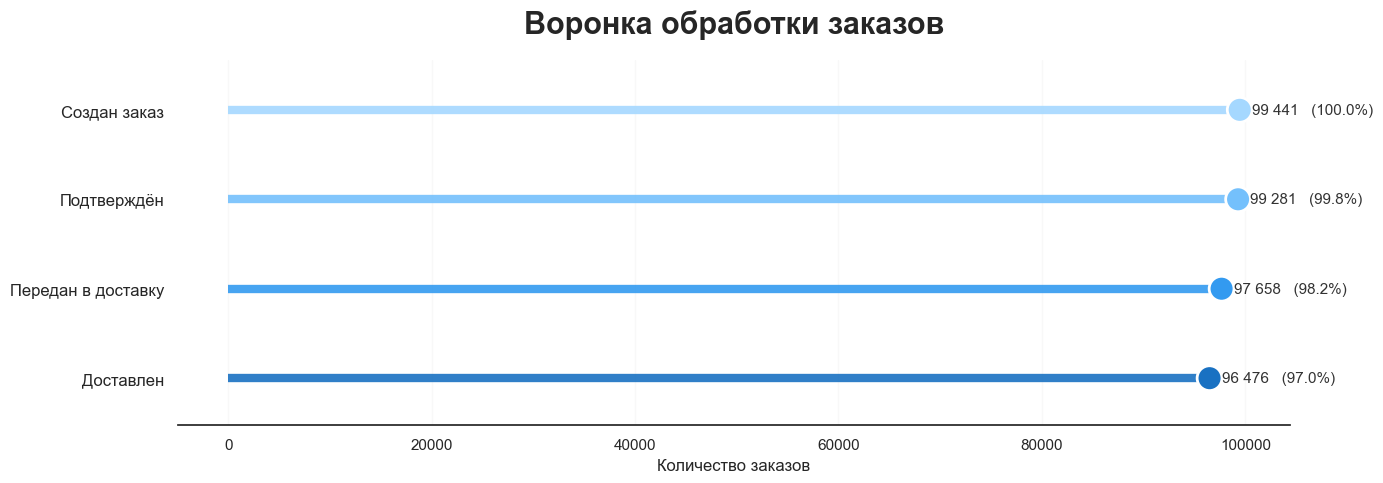

In [179]:
funnel_plot = funnel_df.copy().iloc[::-1]

fig, ax = plt.subplots(figsize=(14, 5), dpi=100)

# palette
colors = [
    '#1971C2',
    '#339AF0',
    '#74C0FC',
    '#A5D8FF'
]

# позиции Y — еще компактнее
y_pos = [0, 0.38, 0.76, 1.14]

# линии
ax.hlines(
    y=y_pos,
    xmin=0,
    xmax=funnel_plot['Количество'],

    color=colors,
    linewidth=6,
    alpha=0.9
)

# точки
ax.scatter(
    funnel_plot['Количество'],
    y_pos,
    s=320,
    color=colors,
    edgecolors='white',
    linewidths=2,
    zorder=3
)

# подписи справа
for i, row in enumerate(funnel_plot.itertuples()):

    ax.text(
        row.Количество + 1200,
        y_pos[i],
        f"{row.Количество:,}".replace(',', ' ')
        + f"   ({row._3:.1f}%)",
        va='center',
        fontsize=11,
        color='#333333'
    )

# оси
ax.set_yticks(y_pos)
ax.set_yticklabels(
    funnel_plot['Этап'],
    fontsize=12
)

# title
ax.set_title(
    'Воронка обработки заказов',
    fontsize=22,
    weight='bold',
    pad=20
)

ax.set_xlabel('Количество заказов')
ax.set_ylabel('')

# limits
ax.set_ylim(-0.2, 1.35)

# стиль
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.grid(axis='y', alpha=0)
ax.grid(axis='x', alpha=0.12)

plt.tight_layout()
plt.show()

Анализ воронки показывает, что большая часть заказов успешно проходит все этапы обработки и доставки.

Наиболее заметное снижение количества заказов наблюдается между этапами:

- создания заказа;
- подтверждения оплаты;
- передачи в доставку.

Это может быть связано:

- с отменами заказов;
- проблемами оплаты;
- логистическими ограничениями;
- отсутствием товаров.

При этом конверсия в успешно доставленные заказы остаётся высокой, что свидетельствует о стабильной работе основных бизнес-процессов платформы.

💡 Возможные продуктовые гипотезы:
- оптимизация процесса оплаты может снизить количество потерь на ранних этапах;
- улучшение логистики способно повысить долю успешно доставленных заказов;
- часть отмен может быть связана с пользовательским опытом или ожиданиями по срокам доставки.

## Географический анализ пользовательской базы

In [126]:
geo = (
    df.groupby('customer_state')
    .agg({
        'customer_unique_id': 'nunique',
        'payment_value': ['sum', 'mean']
    })
)

geo.columns = [
    'users_count',
    'revenue',
    'avg_order_value'
]

geo = geo.reset_index()

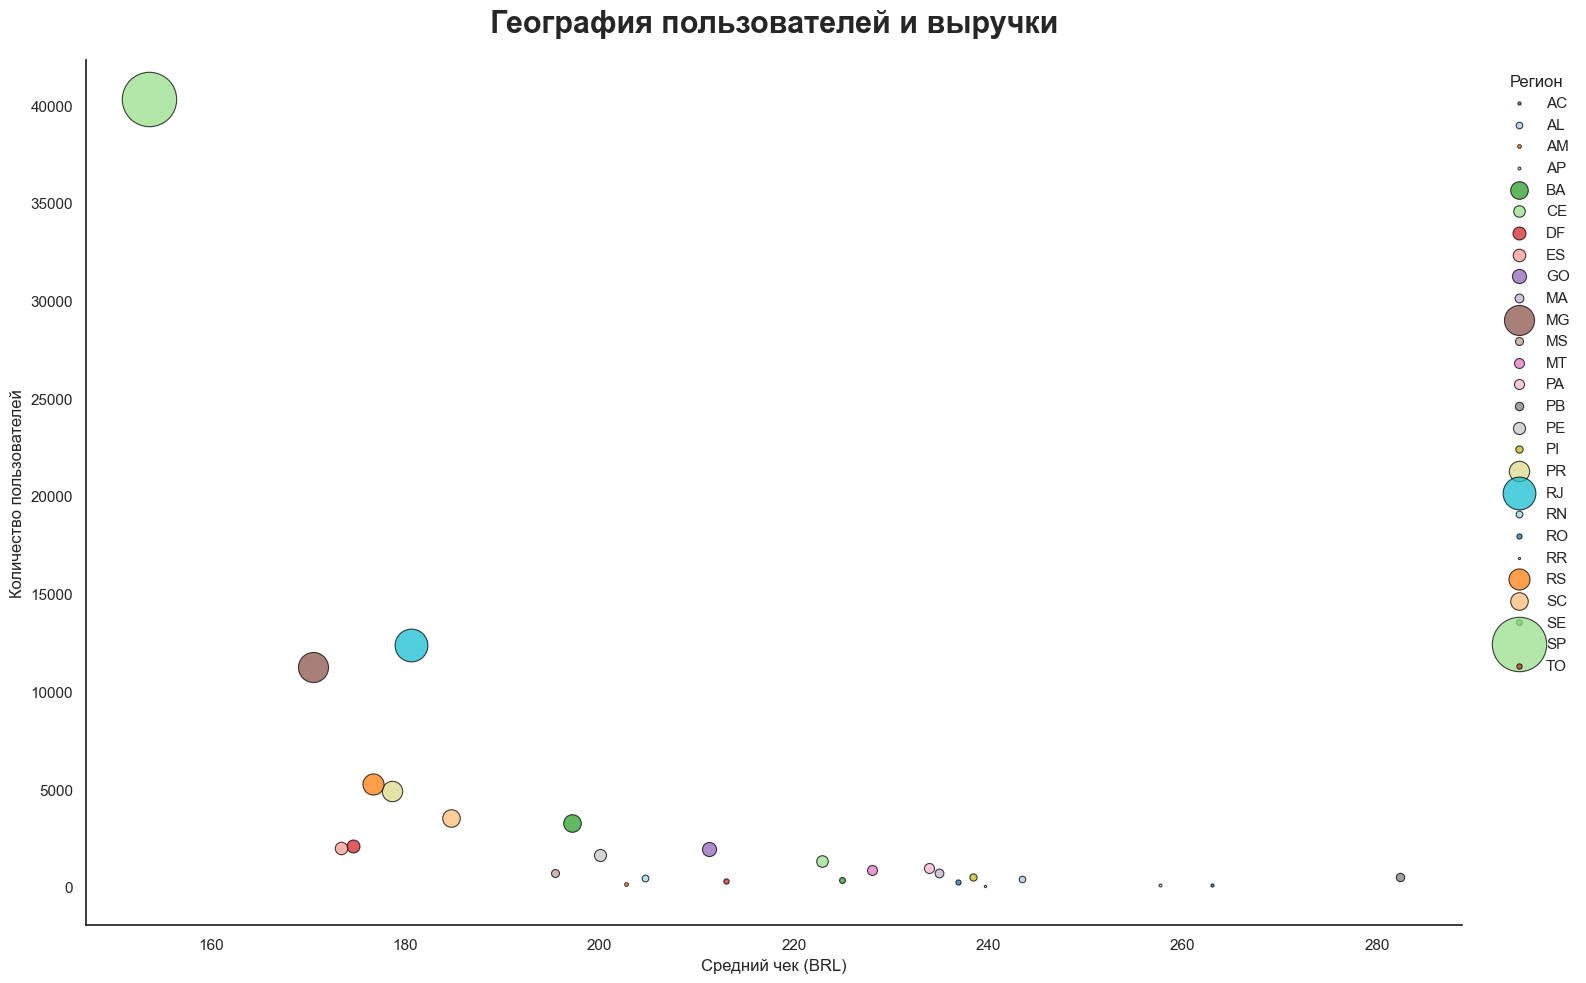

In [129]:
plt.figure(figsize=(16,10))

sns.set_theme(style='white')

# уникальные регионы
states = geo['customer_state'].unique()

# palette
colors = sns.color_palette(
    'tab20',
    n_colors=len(states)
)

# scatter для каждого региона
for state, color in zip(states, colors):

    subset = geo[
        geo['customer_state'] == state
    ]

    plt.scatter(
        subset['avg_order_value'],
        subset['users_count'],

        s=subset['revenue'] / 5000,

        color=color,
        alpha=0.75,

        edgecolors='black',
        linewidths=0.8,

        label=state
    )

plt.title(
    'География пользователей и выручки',
    fontsize=22,
    weight='bold',
    pad=20
)

plt.xlabel('Средний чек (BRL)')
plt.ylabel('Количество пользователей')

# легенда
plt.legend(
    title='Регион',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False
)

sns.despine()

plt.tight_layout()
plt.show()

На графике представлено распределение регионов по трём ключевым метрикам:

- количество пользователей;
- средний чек;
- объём выручки (размер пузыря).

Каждый пузырь соответствует отдельному региону. Чем больше размер пузыря, тем выше суммарная выручка региона.

Абсолютным лидером по количеству пользователей и объёму выручки является регион SP (Сан-Паулу). Он значительно опережает остальные регионы как по масштабу клиентской базы, так и по финансовому вкладу в бизнес маркетплейса.

Также заметно выделяются RJ (Рио-де-Жанейро) и  MG (Минас-Жерайс)

Эти регионы формируют крупную часть пользовательской активности и revenue платформы.

При этом график показывает интересную особенность: регионы с наиболее высоким средним чеком не всегда обладают большой пользовательской базой или высоким объёмом выручки. Это может свидетельствовать о существовании небольших, но более платёжеспособных сегментов пользователей.

Основная масса регионов сосредоточена в диапазоне среднего чека около 170–220 BRL и имеет относительно небольшое количество пользователей по сравнению с лидирующими регионами.

График также демонстрирует высокую концентрацию бизнеса в ограниченном числе регионов, что является как преимуществом, так и потенциальным риском для платформы:

- упрощается логистика и масштабирование в крупнейших регионах;
- возникает зависимость revenue от ограниченного числа ключевых рынков.

💡 Возможные продуктовые гипотезы:
- крупнейшие регионы являются основными драйверами роста маркетплейса;
- регионы с высоким средним чеком могут быть перспективны для premium-сегмента;
- развитие логистики и маркетинга в менее активных регионах способно расширить пользовательскую базу и увеличить revenue;
- персонализированные предложения для high-value регионов могут повысить средний чек и удержание пользователей.

## Когортный анализ

In [68]:
retention_df = orders.merge(
    customers,
    on='customer_id',
    how='left'
)

retention_df = retention_df[
    retention_df['order_status'] == 'delivered'
].copy()

In [69]:
retention_df['order_purchase_timestamp'] = pd.to_datetime(
    retention_df['order_purchase_timestamp']
)

retention_df['order_month'] = (
    retention_df['order_purchase_timestamp']
    .dt.to_period('M')
)

In [72]:
# месяц первой покупки
retention_df['cohort_month'] = (
    retention_df
    .groupby('customer_unique_id')['order_month']
    .transform('min')
)

In [73]:
# сколько месяцев прошло с момента первой покупки
retention_df['cohort_index'] = (
    (
        retention_df['order_month'].dt.year
        - retention_df['cohort_month'].dt.year
    ) * 12
    +
    (
        retention_df['order_month'].dt.month
        - retention_df['cohort_month'].dt.month
    )
    + 1
)

In [ ]:
# считаем пользователей
cohort_data = retention_df.groupby(
    ['cohort_month', 'cohort_index']
)['customer_unique_id'].nunique().reset_index()

In [78]:
# сводная таблица
cohort_table = cohort_data.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='customer_unique_id'
)

In [87]:
# в %
retention_matrix = cohort_table.divide(
    cohort_table.iloc[:, 0],
    axis=0
)

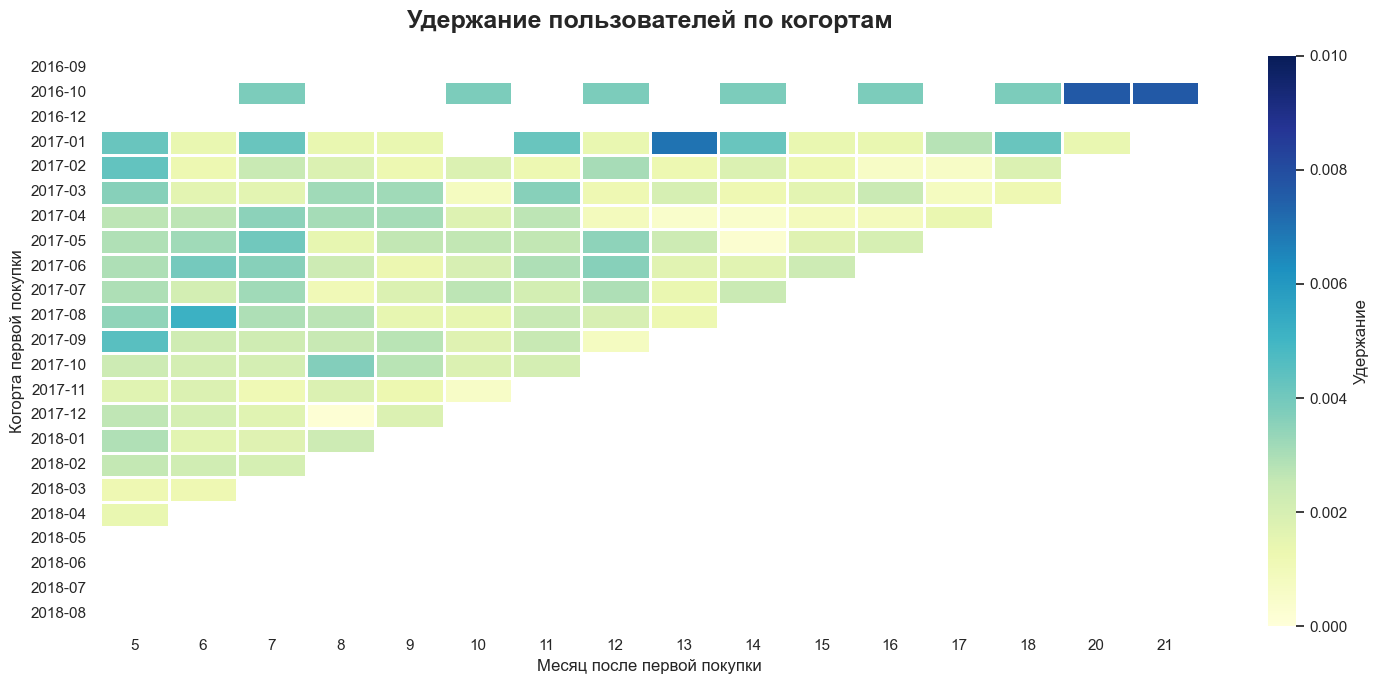

In [175]:
retention_matrix = retention_matrix.iloc[:, 1:]
plt.figure(figsize=(15, 7))
sns.set_theme(style='white')

ax = sns.heatmap(
    retention_matrix.iloc[:, 1:],
    annot=False,
    cmap='YlGnBu',
    vmin=0,
    vmax=0.01,
    linewidths=0.8,
    linecolor='white',
    cbar_kws={'label': 'Удержание'}
)

plt.title('Удержание пользователей по когортам', fontsize=18, pad=20)
plt.xlabel('Месяц после первой покупки')
plt.ylabel('Когорта первой покупки')

plt.tight_layout()
plt.show()

На графике представлена когортная retention-матрица пользователей маркетплейса. Каждая строка отражает пользователей, совершивших первую покупку в определённый месяц, а столбцы показывают последующие месяцы их активности.

Во всех когортах наблюдается резкое снижение retention уже после первого месяца жизни пользователя. Доля клиентов, совершающих повторные покупки, остаётся крайне низкой и в большинстве случаев близка к 0–1%.

Это говорит о том, что основная часть пользователей совершает только одну покупку и не возвращается на платформу повторно.

При этом существенного улучшения retention в более поздних когортах не наблюдается, что может указывать на системную проблему удержания пользователей, а не на временные колебания.

Подобная динамика характерна для маркетплейсов с:

- высокой долей разовых покупок;
- слабой программой лояльности;
- недостаточной персонализацией;
- низкой вовлечённостью после первой покупки.

💡 Возможные продуктовые гипотезы:
- пользователи не получают достаточной ценности после первой покупки;
- отсутствуют эффективные механизмы возврата клиентов;
- коммуникации после покупки недостаточно персонализированы;
- сроки доставки, качество сервиса или ассортимент могут влиять на повторные заказы.

📌 Потенциальные направления улучшений:
- внедрение персональных рекомендаций;
- программы лояльности и бонусов;
- email / push-кампании для возврата пользователей;
- улучшение post-purchase experience;
- оптимизация сроков доставки и клиентского сервиса.

## Анализ revenue и платежного поведения.

In [92]:
revenue_df = orders.merge(
    payments,
    on='order_id',
    how='left'
)

revenue_df = revenue_df[
    revenue_df['order_status'] == 'delivered'
]

In [93]:
monthly_revenue = (
    revenue_df.groupby(
        revenue_df['order_purchase_timestamp'].dt.to_period('M')
    )['payment_value']
    .sum()
)

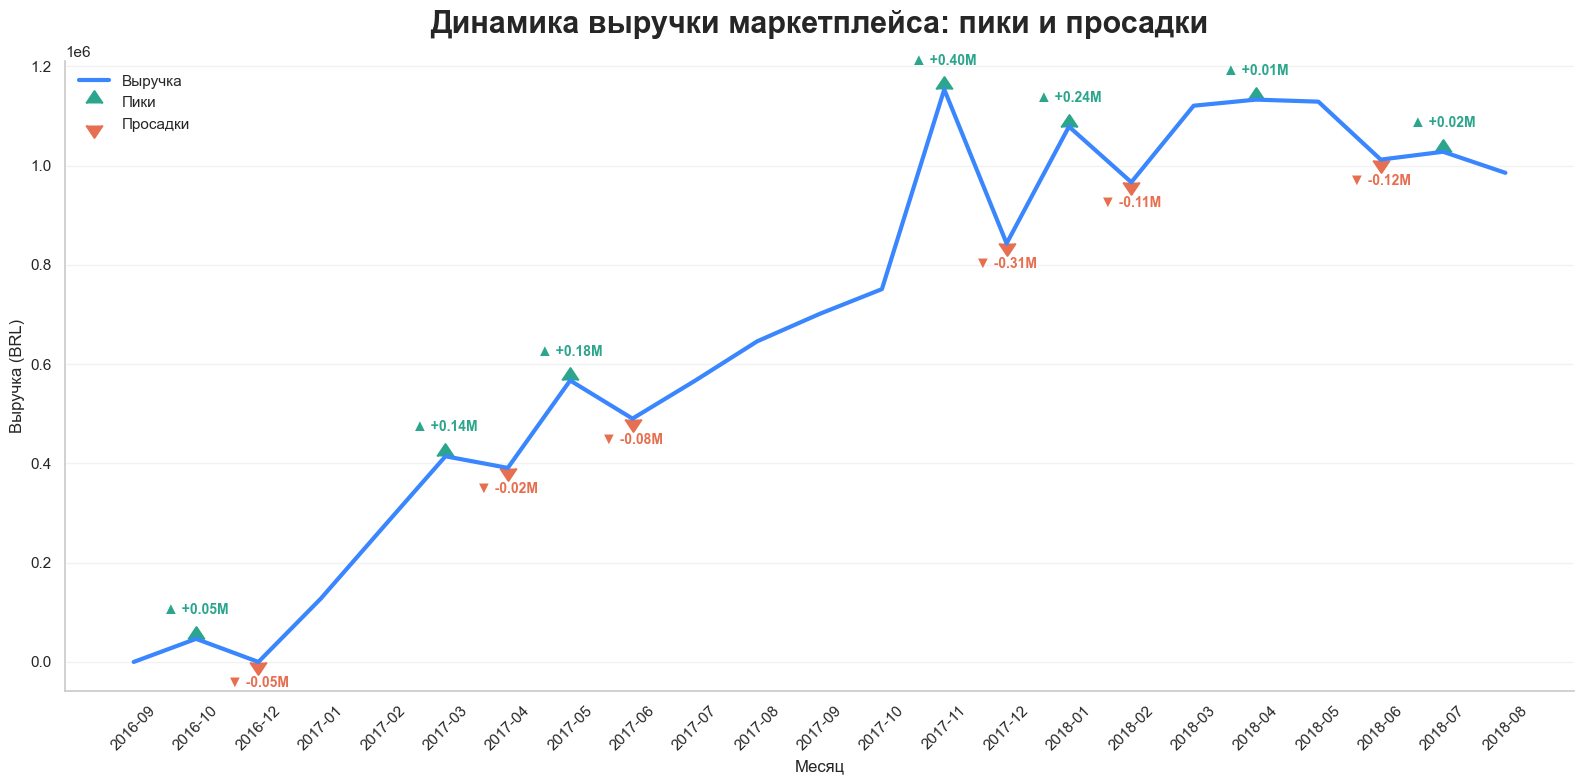

In [174]:
# подготовка данных
revenue_ts = monthly_revenue.reset_index()
revenue_ts.columns = ['month', 'revenue']
revenue_ts['month'] = revenue_ts['month'].astype(str)
revenue_ts['diff'] = (
    revenue_ts['revenue']
    .diff()
)

data = revenue_ts['revenue'].values

# пики
doublediff = np.diff(np.sign(np.diff(data)))
peak_locations = np.where(doublediff == -2)[0] + 1

# впадины
doublediff2 = np.diff(np.sign(np.diff(-1 * data)))
trough_locations = np.where(doublediff2 == -2)[0] + 1

# график
fig, ax = plt.subplots(figsize=(16, 8), dpi=100)

ax.plot(
    revenue_ts['month'],
    revenue_ts['revenue'],
    color='#3A86FF',
    linewidth=3,
    label='Выручка'
)

ax.scatter(
    revenue_ts.loc[peak_locations, 'month'],
    revenue_ts.loc[peak_locations, 'revenue'],
    marker=mpl.markers.CARETUPBASE,
    color='#2CA58D',
    s=140,
    label='Пики'
)

ax.scatter(
    revenue_ts.loc[trough_locations, 'month'],
    revenue_ts.loc[trough_locations, 'revenue'],
    marker=mpl.markers.CARETDOWNBASE,
    color='#E76F51',
    s=140,
    label='Просадки'
)

# подписи только для самых заметных пиков и просадок
for idx in peak_locations:
    change = revenue_ts.loc[idx, 'diff']
    ax.text(
        revenue_ts.loc[idx, 'month'],
        revenue_ts.loc[idx, 'revenue'] + 50000,
        f'▲ +{change/1e6:.2f}M',
        ha='center',
        fontsize=10,
        weight='bold',
        color='#2CA58D'
    )

for idx in trough_locations:
    change = revenue_ts.loc[idx, 'diff']
    ax.text(
        revenue_ts.loc[idx, 'month'],
        revenue_ts.loc[idx, 'revenue'] - 50000,
        f'▼ {change/1e6:.2f}M',
        ha='center',
        fontsize=10,
        weight='bold',
        color='#E76F51'
    )

ax.set_title(
    'Динамика выручки маркетплейса: пики и просадки',
    fontsize=22,
    weight='bold',
    pad=20
)

ax.set_xlabel('Месяц')
ax.set_ylabel('Выручка (BRL)')

ax.tick_params(axis='x', rotation=45)

ax.grid(axis='y', alpha=0.25)
ax.grid(axis='x', alpha=0)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(frameon=False, loc='upper left')

plt.tight_layout()
plt.show()

График демонстрирует устойчивый рост выручки маркетплейса на протяжении анализируемого периода. Начиная с начала 2017 года наблюдается активное увеличение объёма продаж, что может свидетельствовать о росте пользовательской базы, расширении ассортимента и развитии платформы.

Наиболее заметный рост выручки происходит во второй половине 2017 года. Пиковое значение достигается в ноябре 2017 года, после чего наблюдаются краткосрочные колебания, однако общий уровень выручки остаётся стабильно высоким.

Резкий всплеск в ноябре 2017 года, вероятно, связан с сезонными факторами и крупными распродажами, аналогичными Black Friday, которые традиционно значительно увеличивают активность пользователей в e-commerce.

В 2018 году выручка выходит на более стабильный уровень с меньшей волатильностью, что может указывать на постепенное формирование устойчивой пользовательской базы и зрелость бизнес-процессов платформы.

При этом в последние месяцы периода наблюдается небольшое снижение выручки. Это может быть связано:

- с сезонностью;
- снижением пользовательской активности;
- неполнотой данных за последние месяцы.

💡 Возможные продуктовые гипотезы:
- маркетинговые кампании и сезонные акции оказывают существенное влияние на revenue;
- рост retention пользователей способен дополнительно стабилизировать выручку;
- развитие программ лояльности и персонализированных рекомендаций может повысить средний чек и частоту повторных покупок.

In [144]:
# уникальные заказы
df_orders_unique = (
    df[['order_id',
        'customer_state',
        'order_purchase_timestamp',
        'payment_value']]
    .drop_duplicates()
    .copy()
)

# год и месяц
df_orders_unique['year'] = (
    df_orders_unique['order_purchase_timestamp']
    .dt.year
)

df_orders_unique['month'] = (
    df_orders_unique['order_purchase_timestamp']
    .dt.month
)

# берём только январь-август
df_filtered = df_orders_unique[
    (
        df_orders_unique['year'].isin([2017, 2018])
    )
    &
    (
        df_orders_unique['month'] <= 8
    )
]

# revenue по регионам
state_revenue = (
    df_filtered
    .groupby(['customer_state', 'year'])['payment_value']
    .sum()
    .reset_index()
)

# pivot
state_pivot = (
    state_revenue
    .pivot(
        index='customer_state',
        columns='year',
        values='payment_value'
    )
    .fillna(0)
)

# топ регионов
state_pivot['total'] = (
    state_pivot[2017]
    + state_pivot[2018]
)

top_states = (
    state_pivot
    .sort_values('total', ascending=False)
    .head(7)
    .drop(columns='total')
    .sort_values(2017)
)

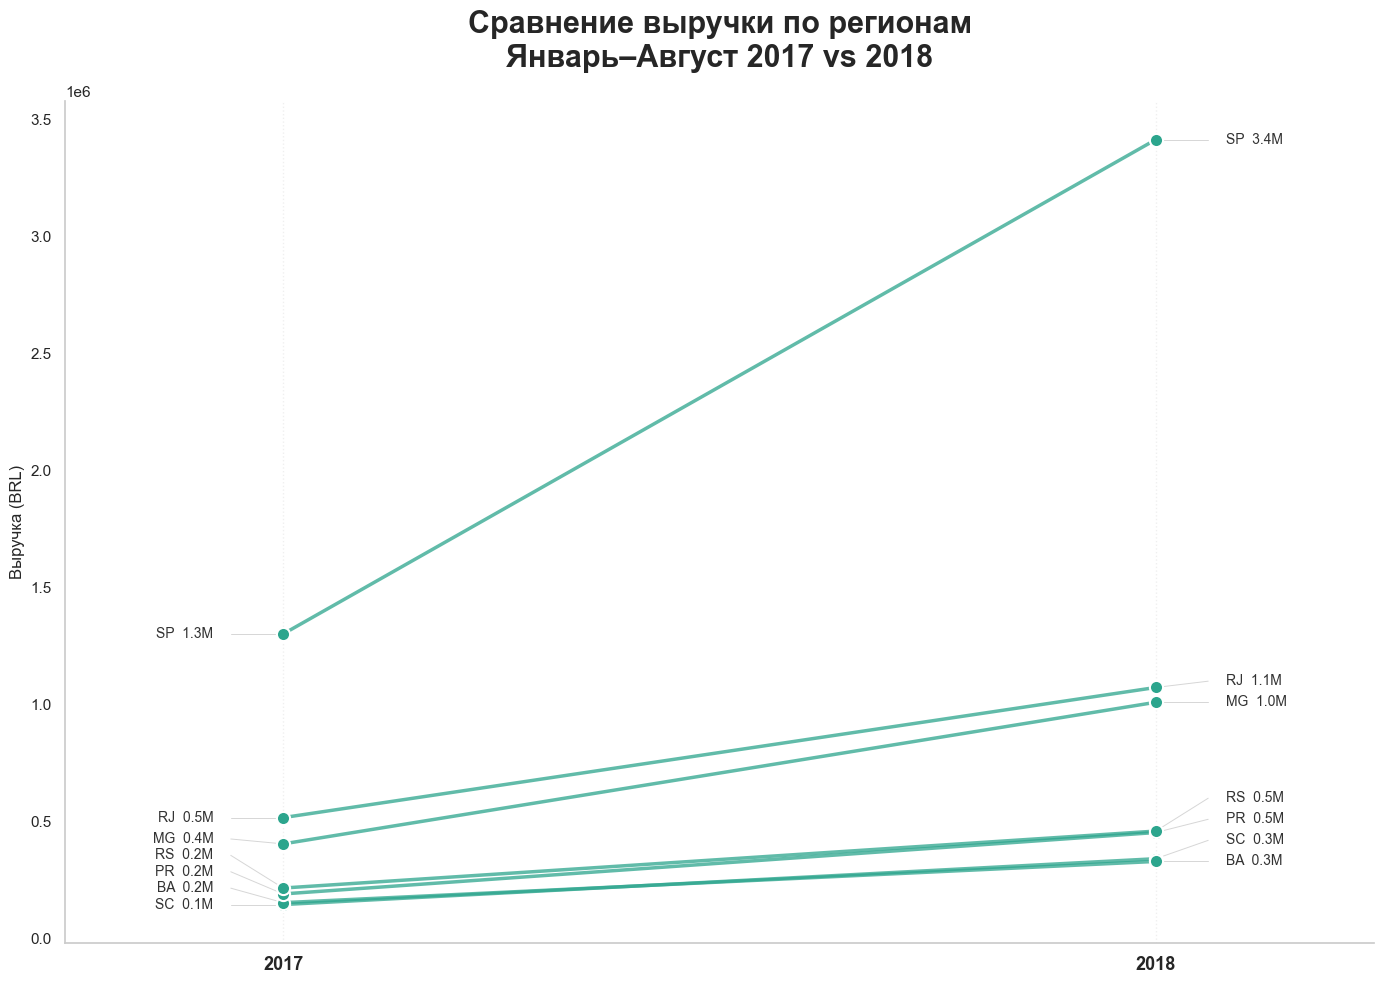

In [165]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

plot_df = (
    top_states
    .reset_index()
    .rename(columns={2017: 'revenue_2017', 2018: 'revenue_2018'})
)

fig, ax = plt.subplots(figsize=(14, 10), dpi=100)

color = '#2CA58D'

for _, row in plot_df.iterrows():
    ax.plot(
        [0, 1],
        [row['revenue_2017'], row['revenue_2018']],
        color=color,
        linewidth=2.5,
        alpha=0.75
    )
    ax.scatter(
        [0, 1],
        [row['revenue_2017'], row['revenue_2018']],
        s=90,
        color=color,
        edgecolor='white',
        linewidth=1.5,
        zorder=3
    )

# функция раздвижения подписей
def spread_labels(values, min_gap):
    values = np.array(values, dtype=float)
    order = np.argsort(values)
    adjusted = values.copy()

    for i in range(1, len(order)):
        prev_idx = order[i - 1]
        curr_idx = order[i]

        if adjusted[curr_idx] - adjusted[prev_idx] < min_gap:
            adjusted[curr_idx] = adjusted[prev_idx] + min_gap

    return adjusted

left_y = spread_labels(plot_df['revenue_2017'], min_gap=70_000)
right_y = spread_labels(plot_df['revenue_2018'], min_gap=90_000)

# подписи слева
for i, row in plot_df.iterrows():
    y_text = left_y[i]

    ax.text(
        -0.08,
        y_text,
        f"{row['customer_state']}  {row['revenue_2017'] / 1e6:.1f}M",
        ha='right',
        va='center',
        fontsize=10,
        color='#333333'
    )

    ax.plot(
        [-0.06, 0],
        [y_text, row['revenue_2017']],
        color='#BBBBBB',
        linewidth=0.7,
        alpha=0.6
    )

# подписи справа
for i, row in plot_df.iterrows():
    y_text = right_y[i]

    ax.text(
        1.08,
        y_text,
        f"{row['customer_state']}  {row['revenue_2018'] / 1e6:.1f}M",
        ha='left',
        va='center',
        fontsize=10,
        color='#333333'
    )

    ax.plot(
        [1, 1.06],
        [row['revenue_2018'], y_text],
        color='#BBBBBB',
        linewidth=0.7,
        alpha=0.6
    )

ax.set_xticks([0, 1])
ax.set_xticklabels(['2017', '2018'], fontsize=13, weight='bold')
ax.set_xlim(-0.25, 1.25)

ax.set_title(
    'Сравнение выручки по регионам\nЯнварь–Август 2017 vs 2018',
    fontsize=22,
    weight='bold',
    pad=25
)

ax.set_ylabel('Выручка (BRL)')
ax.set_xlabel('')

ax.grid(False)
ax.grid(axis='x', linestyle=':', alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()

Сравнение выручки по регионам Январь–Август 2017 vs 2018 (так как 2018 год у нас не полный)

График демонстрирует изменение выручки маркетплейса по крупнейшим регионам за аналогичный период 2017 и 2018 годов.

Во всех представленных регионах наблюдается рост выручки, что свидетельствует о масштабировании бизнеса и увеличении пользовательской активности на платформе.

Абсолютным лидером по объёму revenue остаётся регион SP (Сан-Паулу). За рассматриваемый период его выручка выросла более чем в два раза — с ~1.3M BRL до ~3.4M BRL. Это подтверждает ключевую роль региона как основного драйвера бизнеса маркетплейса.

Значительный рост также демонстрируют:

- RJ (Рио-де-Жанейро)
- MG (Минас-Жерайс)

Оба региона преодолели отметку около 1M BRL выручки в 2018 году, сохранив позиции крупнейших рынков после Сан-Паулу.

Регионы второго уровня (RS, PR, SC, BA) также показывают устойчивый положительный тренд, хотя масштабы их revenue остаются существенно ниже лидеров. Это может указывать на постепенное расширение присутствия маркетплейса и рост проникновения платформы в менее крупные регионы.

График подчёркивает высокую концентрацию выручки в ограниченном числе крупнейших регионов. При этом рост revenue наблюдается практически во всех ключевых локациях, что является позитивным сигналом с точки зрения общего развития платформы.

💡 Возможные бизнес-выводы
- крупнейшие регионы остаются основными драйверами revenue;
- рост выручки носит системный характер, а не ограничивается одним регионом;
- маркетплейс успешно масштабирует бизнес в нескольких ключевых регионах одновременно;
- существует потенциал дальнейшего развития регионов второго уровня.

🚀 Возможные продуктовые гипотезы
- усиление маркетинга в быстрорастущих регионах способно дополнительно увеличить revenue;
- развитие логистики в регионах второго уровня может ускорить рост пользовательской базы;
- персонализированные региональные кампании могут повысить retention и средний чек;
- высокая зависимость от крупнейших регионов требует диверсификации revenue по стране.

In [102]:
user_orders = (
    customer_orders.groupby('customer_unique_id')['order_id']
    .count()
)

repeat_share = (
    user_orders > 1
).mean()

print(f'Repeat users share: {repeat_share:.2%}')

Repeat users share: 3.12%


In [107]:
revenue_users = (
    df[['order_id', 'customer_unique_id', 'payment_value']]
    .drop_duplicates()
    .groupby('customer_unique_id')['payment_value']
    .sum()
    .sort_values(ascending=False)
)

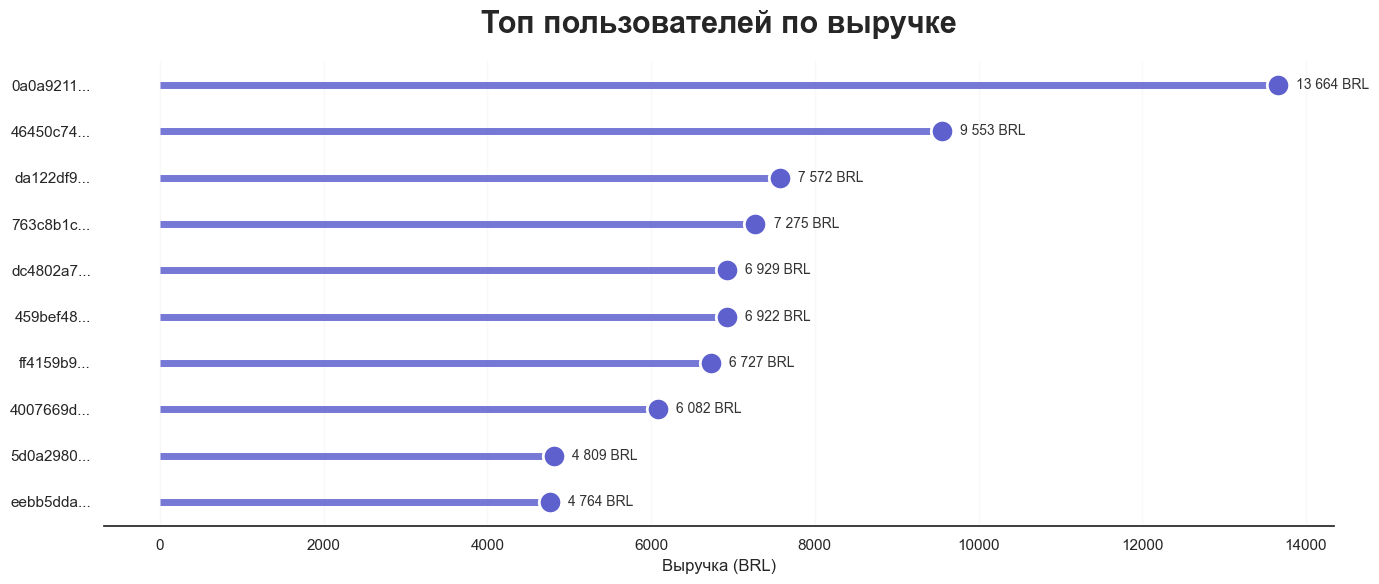

In [182]:
top_users_plot = (
    top_users
    .sort_values()
)

fig, ax = plt.subplots(figsize=(14, 6), dpi=100)

# palette
color = '#5E60CE'

# компактные позиции
y_pos = [i * 0.38 for i in range(len(top_users_plot))]

# линии
ax.hlines(
    y=y_pos,
    xmin=0,
    xmax=top_users_plot.values,

    color=color,
    linewidth=5,
    alpha=0.85
)

# точки
ax.scatter(
    top_users_plot.values,
    y_pos,
    s=260,
    color=color,
    edgecolors='white',
    linewidths=2,
    zorder=3
)

# подписи справа
for i, (user, value) in enumerate(top_users_plot.items()):

    ax.text(
        value + 220,
        y_pos[i],
        f"{value:,.0f}".replace(',', ' ') + ' BRL',
        va='center',
        fontsize=10,
        color='#333333'
    )

# оси
ax.set_yticks(y_pos)

# сокращаем user id
ax.set_yticklabels(
    [u[:8] + '...' for u in top_users_plot.index],
    fontsize=11
)

# title
ax.set_title(
    'Топ пользователей по выручке',
    fontsize=22,
    weight='bold',
    pad=20
)

ax.set_xlabel('Выручка (BRL)')
ax.set_ylabel('')

# limits
ax.set_ylim(-0.2, max(y_pos) + 0.2)

# стиль
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.grid(axis='y', alpha=0)
ax.grid(axis='x', alpha=0.12)

plt.tight_layout()
plt.show()

График демонстрирует распределение выручки среди пользователей с наибольшим объёмом покупок. Видно, что небольшой сегмент клиентов генерирует существенно более высокую выручку по сравнению с остальной пользовательской базой.

Лидер рейтинга значительно опережает остальных пользователей по суммарному объёму покупок, что может свидетельствовать о существовании high-value сегмента клиентов с высокой частотой заказов или крупными чеками.

Подобная концентрация выручки является типичной для e-commerce платформ, где значительная часть дохода формируется ограниченным числом наиболее активных покупателей.

Такие пользователи особенно важны для бизнеса, поскольку:

обеспечивают значительный вклад в revenue;
имеют высокий lifetime value;
чаще совершают повторные покупки.

💡 Возможные продуктовые гипотезы:
- персонализированные предложения для high-value пользователей могут дополнительно увеличить revenue;
- удержание наиболее активных клиентов критически важно для стабильности бизнеса;
- сегмент VIP-пользователей может требовать отдельной стратегии лояльности и сервиса.

## Выводы

В рамках проекта был проведён комплексный анализ пользовательского поведения, заказов, платежей и логистики маркетплейса на основе реальных e-commerce данных. Основной целью исследования являлось выявление факторов, влияющих на выручку, конверсию и удержание пользователей.

В ходе анализа было установлено, что платформа демонстрирует устойчивый рост выручки и количества заказов на протяжении рассматриваемого периода, что свидетельствует о развитии бизнеса и расширении пользовательской базы. Наиболее заметный рост активности наблюдался в периоды сезонных распродаж и маркетинговых кампаний.

Анализ воронки заказов показал, что большая часть заказов успешно проходит все этапы обработки и доставки, однако на отдельных стадиях присутствует отток пользователей, связанный с отменами заказов, логистическими задержками и недоступностью товаров.

Retention-анализ выявил одну из ключевых проблем платформы — низкий уровень возврата пользователей. Большинство клиентов совершают только одну покупку и не возвращаются на маркетплейс повторно. Это может свидетельствовать о недостаточной вовлечённости пользователей, слабой системе удержания и отсутствии эффективных механизмов повторного взаимодействия с клиентами.

Дополнительный анализ показал, что:

- значительная часть выручки формируется ограниченным числом наиболее активных пользователей;
- большинство заказов имеют относительно невысокую стоимость;
- пользователи преимущественно используют оплату банковскими картами;
- сроки доставки в большинстве случаев соответствуют ожиданиям клиентов, однако присутствуют отдельные случаи существенных задержек, потенциально влияющих на пользовательский опыт.

Также была выявлена высокая концентрация пользователей и выручки в крупнейших регионах страны, что указывает на неравномерное распределение клиентской базы и потенциальные точки роста в менее активных регионах.

💡 <b>Основные бизнес-проблемы</b>
- низкий уровень удержания пользователей;
- высокая доля разовых покупателей;
- зависимость revenue от ограниченного сегмента клиентов;
- наличие логистических задержек и отмен заказов.

🚀 <b>Возможные направления улучшения продукта</b>

На основе проведённого анализа можно предложить следующие продуктовые инициативы:

- внедрение программ лояльности для повышения retention;
- развитие персонализированных рекомендаций;
- запуск reactivation-кампаний для возврата пользователей;
- оптимизация логистики и сокращение сроков доставки;
- развитие регионов с низкой пользовательской активностью;
- дополнительная работа с high-value сегментом пользователей.

📊 <b>Итог</b>

В результате проекта были:

- проведены исследовательский и продуктовый анализ данных;
- рассчитаны ключевые метрики маркетплейса;
- исследованы пользовательское поведение, revenue и retention;
- выявлены основные точки роста и проблемные зоны бизнеса;
- подготовлена аналитическая база для дальнейшего построения BI-дашборда и принятия продуктовых решений.